# Лекция 4. Разбор упражнений

Упражнения из раздела 12 конспекта [`lecture04.md`](lecture04.md). Каждое разбирается по одной схеме:

1. **условие**;
2. **решение по шагам** — вручную, как на лекции;
3. **проверка кодом** — тот же вывод получаем численно.

На семинаре у доски разбираются 12.1, 12.3, 12.4, 12.7 и 12.5 (в этом порядке), остальные — 12.2, 12.6, 12.8, 12.9, 12.10 — дома. Сначала попробуйте решить сами. Краткие ответы без кода — в [`exercises04.md`](exercises04.md).

Во всех проверках используются две функции: `gd` — градиентный спуск (постоянный шаг или backtracking по условию Армихо $f(x-\alpha\nabla f)\le f(x)-c\,\alpha\|\nabla f\|^2$, $c=10^{-4}$) и `newton` — чистый метод Ньютона без линейного поиска.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root, minimize
from scipy.special import expit

BLUE, ORANGE, AQUA, RED, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})


def gd(f, grad, x0, alpha=None, tol=1e-6, maxit=100_000, c=1e-4):
    """Градиентный спуск. alpha=None — backtracking: начинаем с 1, делим пополам, пока не
    выполнено условие Армихо с константой c. Иначе — постоянный шаг alpha.
    Возвращает (x, число итераций, путь как массив (k+1, n))."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        if alpha is None:
            a, fx = 1.0, f(x)
            while f(x - a * g) > fx - c * a * (g @ g):
                a /= 2
        else:
            a = alpha
        x = x - a * g; path.append(x.copy())
    return x, maxit, np.array(path)


def newton(grad, hess, x0, tol=1e-10, maxit=50):
    """Чистый метод Ньютона без линейного поиска. Возвращает (x, число итераций, путь)."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        x = x - np.linalg.solve(hess(x), g); path.append(x.copy())
    return x, maxit, np.array(path)

## 12.1. Стационарные точки и седло на пути градиентного спуска

> Стационарные точки $f(x)=(x_1^2-1)^2+x_2^2$ (пример лекции 2, §4). Найдите все точки с $\nabla f=0$, выпишите гессиан в каждой и классифицируйте: минимум, максимум, седло. Сверьте с картой $\lambda_{\min}\nabla^2f$ из лекции 2. Куда придёт градиентный спуск из $(0,\,0.5)$? Из $(0.01,\,0.5)$?

**Решение.**

*Шаг 1. Стационарные точки.* $\nabla f=\big(4x_1(x_1^2-1),\ 2x_2\big)$. Вторая компонента обнуляется только при $x_2=0$; первая — при $x_1=0$ или $x_1=\pm1$. Итого три точки: $(0,0)$, $(1,0)$, $(-1,0)$.

*Шаг 2. Гессиан.* Смешанных производных нет: $\nabla^2f=\operatorname{diag}(12x_1^2-4,\ 2)$.

- В $(0,0)$: $\operatorname{diag}(-4,\,2)$, собственные числа разных знаков — **седло**: вдоль $x_2$ функция растёт ($f=x_2^2$), вдоль $x_1$ убывает ($f=(x_1^2-1)^2$ имеет в нуле локальный максимум, $f(0)=1>f(\pm1)=0$).
- В $(\pm1,0)$: $\operatorname{diag}(8,\,2)\succ0$ — достаточное условие второго порядка выполнено, это **строгие локальные минимумы**. Там $f=0$, а $f\ge0$ всюду, значит оба минимума глобальные.
- Максимумов нет: $f$ растёт на бесконечности и не ограничена сверху.

Это согласуется с картой $\lambda_{\min}\nabla^2f=\min(12x_1^2-4,\,2)$ из лекции 2: она отрицательна в полосе $|x_1|<1/\sqrt3$ (там гессиан индефинитен — область невыпуклости, где живёт седло) и положительна снаружи, где лежат оба минимума.

*Шаг 3. Старт $(0,\,0.5)$.* Первая компонента градиента $4x_1(x_1^2-1)$ равна нулю при $x_1=0$, и шаг $x_1\leftarrow x_1-\alpha\cdot0$ её не меняет. Значит, при **любом** шаге вся траектория лежит на прямой $x_1=0$, где $f=1+x_2^2$ — одномерная парабола с минимумом в $x_2=0$. Метод сходится к $(0,0)$ — стационарной точке, которая не является минимумом. Критерий остановки $\|\nabla f\|\le\varepsilon$ этого не заметит: в седле градиент тоже нулевой.

*Шаг 4. Старт $(0.01,\,0.5)$.* Теперь $x_1\ne0$, и покоординатно $x_1\leftarrow x_1\big(1-4\alpha(x_1^2-1)\big)$. При $|x_1|<1$ скобка $1-4\alpha(x_1^2-1)=1+4\alpha(1-x_1^2)>1$: модуль $x_1$ **растёт** на каждом шаге, знак сохраняется. Тем временем при постоянном $0<\alpha<1$ вторая координата $x_2\leftarrow(1-2\alpha)x_2\to0$ монотонно затухает. Точка уходит от седла и приходит в ближайший минимум с тем же знаком $x_1$ — в $(1,0)$.

*Что делает backtracking.* В проверке ниже шаг выбирается по Армихо, начиная с $\alpha=1$, и это стоит проследить руками. Из $(0,0.5)$ пробный шаг $\alpha=1$ даёт $x_2\leftarrow(1-2)\cdot0.5=-0.5$ — точка $(0,-0.5)$ симметрична стартовой, $f$ не убывает, Армихо её отвергает; следующий пробный $\alpha=1/2$ даёт $x_2\leftarrow0$ — седло достигнуто ровно за **одну** итерацию. Из $(0.01,0.5)$ первые пробные шаги $\alpha=1$ принимаются (за счёт роста $x_1$ функция всё же убывает), и $x_2$ гоняется между $\pm0.5$: $0.5\to-0.5\to0.5\to-0.5$; лишь потом шаг укорачивается и $x_2$ затухает — см. первые пять значений $x_2$ в печати.

*Мораль.* Градиентный спуск сходится к стационарной точке, а не обязательно к минимуму. Но к седлу он приходит только со множества стартов меры нуль (здесь — прямая $x_1=0$): седло **неустойчиво** для GD, любое возмущение уводит от него, потому что вдоль направления с $\lambda<0$ ошибка умножается на число, большее единицы. «Мера нуль» реализуется и в арифметике с плавающей точкой: при $x_1=0$ компонента градиента $4\cdot0\cdot(0-1)$ равна нулю **точно**, а не с ошибкой округления, поэтому $x_1$ остаётся нулём на всех итерациях и метод честно приходит в седло.

In [2]:
f1 = lambda x: (x[0] ** 2 - 1) ** 2 + x[1] ** 2
g1 = lambda x: np.array([4 * x[0] * (x[0] ** 2 - 1), 2 * x[1]])
h1 = lambda x: np.array([[12 * x[0] ** 2 - 4, 0.0], [0.0, 2.0]])

# стационарные точки: решаем grad f = 0 из разных стартов
found = []
for s in ([0.2, 0.3], [0.7, -0.4], [-0.8, 0.2], [1.5, 1.0], [-1.5, -1.0]):
    xs = root(g1, s).x
    if not any(np.allclose(xs, q, atol=1e-6) for q in found):
        found.append(xs)
print("стационарные точки, гессианы и классификация:")
for xs in sorted(found, key=lambda q: q[0]):
    lam = np.linalg.eigvalsh(h1(xs))
    kind = "минимум" if lam.min() > 0 else ("максимум" if lam.max() < 0 else "седло")
    print(f"  x = {xs.round(6)},  f = {f1(xs):.4f},  lambda = {lam.round(3)}  ->  {kind}")

# два запуска GD с backtracking
xa, ka, pa = gd(f1, g1, [0.0, 0.5])
xb, kb, pb = gd(f1, g1, [0.01, 0.5])
print(f"GD из (0, 0.5):    x = {xa.round(6)}, итераций {ka}, f = {f1(xa):.4f}  -> седло")
print(f"GD из (0.01, 0.5): x = {xb.round(6)}, итераций {kb}, f = {f1(xb):.2e}  -> минимум (1, 0)")
assert np.allclose(xa, [0, 0], atol=1e-6) and np.allclose(xb, [1, 0], atol=1e-5)

# backtracking по шагам: из (0, 0.5) alpha = 1 отвергнут (f(0,-0.5) = f(0,0.5)), alpha = 1/2 обнуляет x2 сразу
x = np.array([0.0, 0.5]); g = g1(x)
print(f"из (0, 0.5): пробный alpha = 1 даёт x = {x - g}, f = {f1(x - g):.3f} = f(x) = {f1(x):.3f} — Армихо отвергает;"
      f" alpha = 1/2 даёт x = {x - 0.5 * g} — седло за одну итерацию")
print("из (0.01, 0.5): первые пять x2:", pb[:5, 1], " — alpha = 1 гоняет x2 между ±0.5, затем шаг укорачивается и x2 затухает")
print("почему «мера нуль» видна и в float: компонента градиента по x1 при x1 = 0 равна", 4 * 0.0 * (0.0 ** 2 - 1), "— ровно нуль, а не 1e-17")

стационарные точки, гессианы и классификация:
  x = [-1. -0.],  f = 0.0000,  lambda = [2. 8.]  ->  минимум
  x = [0. 0.],  f = 1.0000,  lambda = [-4.  2.]  ->  седло
  x = [1. 0.],  f = 0.0000,  lambda = [2. 8.]  ->  минимум
GD из (0, 0.5):    x = [0. 0.], итераций 1, f = 1.0000  -> седло
GD из (0.01, 0.5): x = [1. 0.], итераций 16, f = 9.31e-16  -> минимум (1, 0)
из (0, 0.5): пробный alpha = 1 даёт x = [ 0.  -0.5], f = 1.250 = f(x) = 1.250 — Армихо отвергает; alpha = 1/2 даёт x = [0. 0.] — седло за одну итерацию
из (0.01, 0.5): первые пять x2: [ 0.5  -0.5   0.5  -0.5  -0.25]  — alpha = 1 гоняет x2 между ±0.5, затем шаг укорачивается и x2 затухает
почему «мера нуль» видна и в float: компонента градиента по x1 при x1 = 0 равна -0.0 — ровно нуль, а не 1e-17


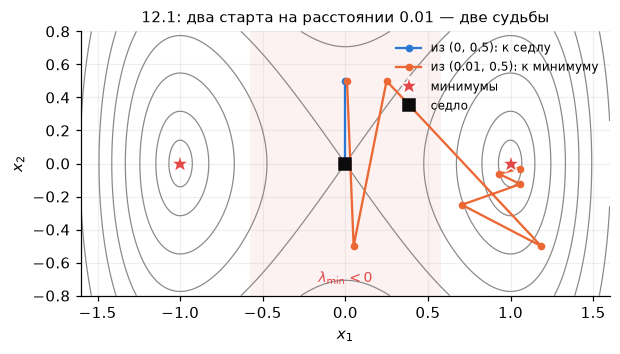

In [3]:
xx, yy = np.meshgrid(np.linspace(-1.6, 1.6, 300), np.linspace(-0.8, 0.8, 200))
zz = (xx ** 2 - 1) ** 2 + yy ** 2
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.contour(xx, yy, zz, levels=np.r_[0.02, 0.1, 0.3, 0.6, 1.0, 1.5, 2.5], colors=GRAY, linewidths=0.8)
ax.plot(pa[:, 0], pa[:, 1], "-o", ms=4, color=BLUE, label="из $(0,\,0.5)$: к седлу")
ax.plot(pb[:, 0], pb[:, 1], "-o", ms=4, color=ORANGE, label="из $(0.01,\,0.5)$: к минимуму")
ax.plot([1, -1], [0, 0], "*", ms=13, color=RED, mec="white", ls="none", label="минимумы")
ax.plot([0], [0], "s", ms=8, color=INK, ls="none", label="седло")
ax.axvspan(-1 / np.sqrt(3), 1 / np.sqrt(3), color=RED, alpha=0.07, lw=0)
ax.text(0, -0.72, "$\lambda_{\min}<0$", ha="center", color=RED, fontsize=9)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=8); ax.set_title("12.1: два старта на расстоянии 0.01 — две судьбы", fontsize=10)
plt.show()

## 12.2. Зазор между необходимым и достаточным условием

> Зазор между необходимым и достаточным условием. (а) Для $x^4$, $x^3$, $-x^4$ в нуле: что говорят условия первого и второго порядка и что на самом деле? (б) То же для $f(x)=x_1^2+x_2^4$ и $g(x)=x_1^2-x_2^4$ в нуле: гессианы одинаковы, а судьбы разные. (в) Пример Пеано: $f(x)=(x_2-x_1^2)(x_2-2x_1^2)$. Покажите, что $\nabla f(0)=0$ и $\nabla^2f(0)=\operatorname{diag}(0,2)\succeq0$; что вдоль любой прямой через нуль функция имеет в нуле строгий локальный минимум; и что нуль всё же не локальный минимум — найдите точки сколь угодно близко к нулю с $f<0$. Что это говорит о проверке «по направлениям»?

**Решение.**

Напомним три условия для точки $x^\ast$: **первого порядка** (необходимое) $\nabla f(x^\ast)=0$; **второго порядка необходимое** $\nabla^2f(x^\ast)\succeq0$; **второго порядка достаточное** $\nabla f(x^\ast)=0$ и $\nabla^2f(x^\ast)\succ0$. Между вторым и третьим — зазор: гессиан с нулевым собственным числом удовлетворяет необходимому, но не достаточному условию, и тогда условия второго порядка ничего не решают.

*(а)* У всех трёх функций $f'(0)=0$ и $f''(0)=0$: $(x^4)''=12x^2$, $(x^3)''=6x$, $(-x^4)''=-12x^2$ — все нули в нуле. Первое условие выполнено; необходимое второе ($f''\ge0$) выполнено; достаточное ($f''>0$) — нет. Условия молчат, и действительно судьбы разные: $x^4\ge0=f(0)$ — **минимум**; $x^3$ меняет знак — **не экстремум** (перегиб); $-x^4\le0$ — **максимум**. Решает поведение старших членов Тейлора, которых условия второго порядка не видят.

*(б)* $\nabla f=(2x_1,\,4x_2^3)$, $\nabla g=(2x_1,\,-4x_2^3)$ — обе стационарны в нуле. $\nabla^2f=\operatorname{diag}(2,\,12x_2^2)$, $\nabla^2g=\operatorname{diag}(2,\,-12x_2^2)$; в нуле **оба** равны $\operatorname{diag}(2,\,0)\succeq0$. Необходимое условие выполнено у обеих, достаточное — ни у одной. При этом $f=x_1^2+x_2^4\ge0=f(0)$ — минимум (сумма неотрицательных слагаемых), а $g(0,x_2)=-x_2^4<0$ — вдоль оси $x_2$ функция убывает в обе стороны, значит ноль — **седло**: по $x_1$ рост, по $x_2$ спад. Вдоль направления с нулевым собственным числом гессиан ничего не гарантирует, и там всё решает четвёртая степень.

*(в) Пример Пеано.* Раскроем скобки: $f=x_2^2-3x_1^2x_2+2x_1^4$.

- *Градиент и гессиан в нуле.* $\nabla f=\big(-6x_1x_2+8x_1^3,\ 2x_2-3x_1^2\big)$, в нуле — нуль. Вторые производные: $f_{x_1x_1}=-6x_2+24x_1^2$, $f_{x_1x_2}=-6x_1$, $f_{x_2x_2}=2$; в нуле $\nabla^2f(0)=\operatorname{diag}(0,\,2)\succeq0$. Необходимые условия выполнены, достаточное — нет: вырожденное направление $e_1$.
- *Вдоль любой прямой через нуль — строгий минимум.* Прямая $x_2=mx_1$: $f(x_1,mx_1)=(mx_1-x_1^2)(mx_1-2x_1^2)=x_1^2(m-x_1)(m-2x_1)$. При $m\ne0$ и малых $x_1$ скобки близки к $m$, так что $f\approx m^2x_1^2>0$ — строгий минимум в $x_1=0$. При $m=0$ (ось $x_1$): $f=2x_1^4>0$. Вертикальная прямая $x_1=0$: $f=x_2^2>0$. Итак, ограничение $f$ на **каждую** прямую через нуль имеет там строгий локальный минимум.
- *Но нуль не минимум.* Функция — произведение двух скобок; она отрицательна ровно там, где скобки разных знаков, то есть между параболами $x_1^2<x_2<2x_1^2$. Возьмём среднюю параболу $x_2=\tfrac32x_1^2$: $f=\big(\tfrac12x_1^2\big)\big(-\tfrac12x_1^2\big)=-\tfrac14x_1^4<0$ при любом $x_1\ne0$. Точки $(x_1,\tfrac32x_1^2)$ подходят к нулю сколь угодно близко, и $f$ там отрицательна: нуль — **не локальный минимум**.
- *Что это значит.* Проверка «по направлениям» (ограничить $f$ на прямые и посмотреть, минимум ли там) — это не достаточное условие: в двумерии к нулю можно подходить не только по прямым, но и по кривым, и область $f<0$ между двумя параболами касается нуля так, что ни одна прямая в неё «не влезает» вблизи нуля. Направленные вторые производные $d^\top\nabla^2f(0)\,d=2d_2^2\ge0$ обнуляются при $d=e_1$, и там всё решают члены четвёртого порядка, которые ведут себя по-разному на прямых и на параболах. Без $\nabla^2f(0)\succ0$ гарантии нет; строгая положительная определённость нужна именно потому, что она даёт **равномерную** по направлениям нижнюю оценку $\tfrac{\lambda_{\min}}2\|d\|^2$, которую не портят члены высшего порядка.

In [4]:
ts = np.array([-0.2, -0.1, -0.05, 0.0, 0.05, 0.1, 0.2])
print("(а)  t        x^4          x^3         -x^4")
for t in ts:
    print(f"   {t:5.2f}  {t**4:10.2e}  {t**3:11.2e}  {-t**4:11.2e}")
print("   -> минимум, не экстремум (меняет знак), максимум; при этом f'(0) = f''(0) = 0 у всех трёх")

f2 = lambda x: x[0] ** 2 + x[1] ** 4
g2 = lambda x: x[0] ** 2 - x[1] ** 4
hess_num = lambda F, x, h=1e-4: np.array([[(F(x + h * ei + h * ej) - F(x + h * ei - h * ej) - F(x - h * ei + h * ej) + F(x - h * ei - h * ej)) / (4 * h * h)
                                            for ej in np.eye(2)] for ei in np.eye(2)])
z = np.zeros(2)
print()
print("(б)  гессиан f в нуле (конечные разности):", hess_num(f2, z).round(6).tolist(), " собственные числа", np.linalg.eigvalsh(hess_num(f2, z)).round(6))
print("     гессиан g в нуле (конечные разности):", hess_num(g2, z).round(6).tolist(), " собственные числа", np.linalg.eigvalsh(hess_num(g2, z)).round(6))
print("     вдоль оси x2 (x1 = 0):  t     f(0,t)     g(0,t)")
for t in (0.05, 0.1, 0.2):
    print(f"                             {t:4.2f}  {f2([0, t]):9.2e}  {g2([0, t]):9.2e}")
print("     -> f растёт от нуля (минимум), g убывает (седло), гессианы одинаковы")

# (в): пример Пеано
fp = lambda x: (x[1] - x[0] ** 2) * (x[1] - 2 * x[0] ** 2)
gp = lambda x: np.array([-6 * x[0] * x[1] + 8 * x[0] ** 3, 2 * x[1] - 3 * x[0] ** 2])
grad_num = lambda F, x, h=1e-6: np.array([(F(x + h * e) - F(x - h * e)) / (2 * h) for e in np.eye(2)])
print()
print("(в)  Пеано: grad f(0) аналитически", gp(z), " конечные разности", grad_num(fp, z).round(10))
print("     hess f(0) конечные разности:", hess_num(fp, z).round(6).tolist(), " = diag(0, 2), собственные числа", np.linalg.eigvalsh(hess_num(fp, z)).round(6))
# вдоль десятка прямых через нуль f > 0 при 0 < |t| <= 0.1
ts = np.r_[-np.logspace(-3, -1, 7), np.logspace(-3, -1, 7)]
ok = True
for th in np.linspace(0, np.pi, 11)[:-1]:
    d = np.array([np.cos(th), np.sin(th)])
    ok &= all(fp(t * d) > 0 for t in ts)
print(f"     вдоль 10 прямых через нуль (углы 0, 18, ..., 162 градусов) при 0 < |t| <= 0.1: везде f > 0 — {ok}")
assert ok
# ...но между параболами f < 0 сколь угодно близко к нулю
print("     на параболе x2 = 1.5 x1^2:  x1        f(x1, 1.5 x1^2)   -x1^4/4")
for t in (0.1, 0.01, 0.001):
    print(f"                                {t:5.3f}   {fp(np.array([t, 1.5 * t * t])):14.3e}   {-t ** 4 / 4:10.3e}")
assert all(fp(np.array([t, 1.5 * t * t])) < 0 for t in (0.1, 0.01, 0.001))
print("     -> нуль не локальный минимум, хотя на любой прямой через нуль он строгий минимум")

(а)  t        x^4          x^3         -x^4
   -0.20    1.60e-03    -8.00e-03    -1.60e-03
   -0.10    1.00e-04    -1.00e-03    -1.00e-04
   -0.05    6.25e-06    -1.25e-04    -6.25e-06
    0.00    0.00e+00     0.00e+00    -0.00e+00
    0.05    6.25e-06     1.25e-04    -6.25e-06
    0.10    1.00e-04     1.00e-03    -1.00e-04
    0.20    1.60e-03     8.00e-03    -1.60e-03
   -> минимум, не экстремум (меняет знак), максимум; при этом f'(0) = f''(0) = 0 у всех трёх

(б)  гессиан f в нуле (конечные разности): [[2.0, 0.0], [0.0, 0.0]]  собственные числа [0. 2.]
     гессиан g в нуле (конечные разности): [[2.0, 0.0], [0.0, -0.0]]  собственные числа [-0.  2.]
     вдоль оси x2 (x1 = 0):  t     f(0,t)     g(0,t)
                             0.05   6.25e-06  -6.25e-06
                             0.10   1.00e-04  -1.00e-04
                             0.20   1.60e-03  -1.60e-03
     -> f растёт от нуля (минимум), g убывает (седло), гессианы одинаковы

(в)  Пеано: grad f(0) аналитически [0. 0.]  

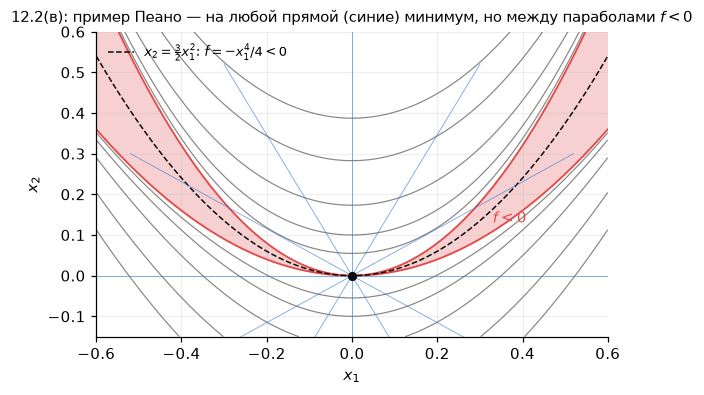

In [5]:
xx, yy = np.meshgrid(np.linspace(-0.6, 0.6, 400), np.linspace(-0.15, 0.6, 400))
zz = (yy - xx ** 2) * (yy - 2 * xx ** 2)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.contourf(xx, yy, zz, levels=[zz.min(), 0], colors=[RED], alpha=0.25)
ax.contour(xx, yy, zz, levels=np.r_[0.003, 0.01, 0.03, 0.08, 0.15], colors=GRAY, linewidths=0.8)
xs = np.linspace(-0.6, 0.6, 200)
ax.plot(xs, xs ** 2, color=RED, lw=1.2); ax.plot(xs, 2 * xs ** 2, color=RED, lw=1.2)
ax.plot(xs, 1.5 * xs ** 2, "--", color=INK, lw=1, label="$x_2=\\frac{3}{2}x_1^2$: $f=-x_1^4/4<0$")
for th in np.linspace(0, np.pi, 7)[:-1]:
    ax.plot([-0.6 * np.cos(th), 0.6 * np.cos(th)], [-0.6 * np.sin(th), 0.6 * np.sin(th)], color=BLUE, lw=0.6, alpha=0.6)
ax.plot(0, 0, "o", color=INK, ms=5)
ax.text(0.33, 0.13, "$f<0$", color=RED, fontsize=10)
ax.set_xlim(-0.6, 0.6); ax.set_ylim(-0.15, 0.6)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("12.2(в): пример Пеано — на любой прямой (синие) минимум, но между параболами $f<0$", fontsize=9.5)
plt.show()

## 12.3. Градиентный спуск на квадратичной: множитель сжатия и зигзаг

> Градиентный спуск на $f(x)=\tfrac12(x_1^2+\kappa x_2^2)$, $\kappa\ge1$, с постоянным шагом $\alpha$. (а) Выпишите итерацию покоординатно. (б) При каких $\alpha$ метод сходится из любой точки? (в) Какой $\alpha$ даёт наименьший множитель сжатия $\max(|1-\alpha|,\,|1-\alpha\kappa|)$ и чему он равен? Нарисуйте оба множителя как функции $\alpha$. (г) Сколько итераций нужно на одну верную десятичную цифру при $\kappa=50$ для $\alpha=1/\kappa$ и для лучшего $\alpha$? Почему при обоих шагах $f$ сжимается за итерацию в квадрат множителя для ошибки? (д) Единицы измерения: пусть $f=\tfrac12(x_1^2+x_2^2)$, обе координаты — метры, $\kappa=1$. Перепишите $f$ через $u_1=x_1/1000$ (километры), $u_2=x_2$: чему равно $\kappa$ и сколько итераций на одну цифру? Покажите, что шаг $u\leftarrow u-\alpha D^{-1}\nabla_uf(u)$ с $D=\operatorname{diag}(10^6,1)$ — это спуск в исходных переменных, а при $D=\nabla^2f$ и $\alpha=1$ — шаг Ньютона (раздел 7).

**Решение.**

*(а) Итерация покоординатно.* $\nabla f=(x_1,\ \kappa x_2)=Qx$ с $Q=\operatorname{diag}(1,\kappa)$, $\lambda_{\min}=1$, $\lambda_{\max}=\kappa$, число обусловленности $\kappa$. Шаг $x\leftarrow x-\alpha Qx=(I-\alpha Q)x$ расщепляется:
$$x_1^{(k+1)}=(1-\alpha)\,x_1^{(k)},\qquad x_2^{(k+1)}=(1-\alpha\kappa)\,x_2^{(k)}.$$
Минимум в нуле, так что ошибка $e_k=x_k$: $x_1^{(k)}=(1-\alpha)^kx_1^{(0)}$, $x_2^{(k)}=(1-\alpha\kappa)^kx_2^{(0)}$ — две независимые геометрические прогрессии.

*(б) Сходимость из любой точки.* Нужно $|1-\alpha|<1$ и $|1-\alpha\kappa|<1$, то есть $0<\alpha<2$ и $0<\alpha<2/\kappa$. Так как $\kappa\ge1$, второе строже: $0<\alpha<2/\kappa=2/\lambda_{\max}$. При $\alpha>2/\kappa$ координата $x_2$ раскачивается с растущей амплитудой — метод расходится, каким бы малым ни был старт.

*(в) Лучший шаг.* Ошибка в целом сжимается не хуже, чем в $\rho(\alpha)=\max(|1-\alpha|,\,|1-\alpha\kappa|)$ раз за итерацию. Нарисуем оба множителя как функции $\alpha$ (картинка ниже, $\kappa=50$): $|1-\alpha|$ — пологая ломаная с нулём в $\alpha=1$, $|1-\alpha\kappa|$ — крутая ломаная с нулём в $\alpha=1/\kappa$, которая выходит за единицу при $\alpha=2/\kappa$ — это и есть граница сходимости из (б). На отрезке $0<\alpha<2/\kappa$ первая величина $1-\alpha$ убывает, вторая $|1-\alpha\kappa|$ сначала убывает до нуля при $\alpha=1/\kappa$, затем растёт как $\alpha\kappa-1$. Максимум двух функций минимален там, где они равны: $1-\alpha=\alpha\kappa-1$, откуда
$$\alpha^\ast=\frac2{\kappa+1},\qquad \rho(\alpha^\ast)=1-\frac2{\kappa+1}=\frac{\kappa-1}{\kappa+1}.$$
Это известная оценка для постоянного шага: при $\kappa\to\infty$ множитель $\approx1-2/\kappa$. При $\kappa=50$: $\alpha^\ast=2/51\approx0.039$, чуть левее границы $2/\kappa=0.04$.

*(г) Итераций на цифру при $\kappa=50$.* Уменьшить ошибку в 10 раз при множителе $\rho$ — это $n$ итераций с $\rho^n=0.1$, $n=\ln10/(-\ln\rho)$.
- $\alpha=1/\kappa=0.02$: $1-\alpha\kappa=0$ (координата $x_2$ обнуляется за один шаг), $1-\alpha=0.98$; $n=\ln10/(-\ln0.98)\approx2.303/0.0202\approx114$ итераций на цифру.
- $\alpha^\ast=2/51\approx0.0392$: $\rho=49/51\approx0.9608$; $n\approx2.303/0.0400\approx58$ итераций на цифру — вдвое быстрее, но всё равно порядка $\kappa$.

*Почему множитель для $f$ — квадрат множителя для ошибки.* Минимум в нуле, $f^\ast=0$, и $f(x)=\tfrac12x^\top Qx=\tfrac12\|e\|_Q^2$ — **квадратичная** функция ошибки $e=x$. Если ошибка вдоль собственного направления $\lambda_i$ умножается на $1-\alpha\lambda_i$, то её квадрат — на $(1-\alpha\lambda_i)^2$, и потому $f(x_{k+1})\le\rho^2f(x_k)$: при $\alpha=1/\kappa$ — множитель $0.98^2=0.9604$, при $\alpha^\ast$ — $(49/51)^2\approx0.923$. Отсюда же: критерий «$f$ уменьшилась в $10^{12}$ раз» — то же самое, что «ошибка уменьшилась в $10^6$ раз», цифр по $f$ получается вдвое больше, а итераций на цифру по $f$ — вдвое меньше. То же верно и для $\|\nabla f\|=\|Qe\|$: она линейна по ошибке и сжимается с тем же множителем $\rho$, что и $\|e\|$.

*Почему точный шаг не быстрее лучшего постоянного.* Точный линейный поиск ($\alpha_k=g^\top g/g^\top Qg$) по неравенству Канторовича сжимает $f$ не хуже, чем в $\big(\tfrac{\kappa-1}{\kappa+1}\big)^2$ раз за шаг, — то есть ровно в квадрат множителя лучшего постоянного шага. Из старта $(\kappa,1)$ эта оценка достигается на **каждой** итерации: точки зигзага $(\kappa,\pm1)\cdot c_k$ лежат на двух прямых, где градиент составляет одинаковые «углы» с обоими собственными направлениями, и это худший случай для Канторовича. Постоянный шаг $\alpha^\ast$ из той же точки даёт для $\|e\|$ множитель $\rho^\ast$ на каждой итерации (обе координаты сжимаются с одним модулем $49/51$), а для $f$ — его квадрат. Скорости совпадают, и в проверке оба варианта доходят до $\|\nabla f\|\le10^{-8}$ за одни и те же **567** итераций; точный поиск выигрывает лишь в том, что ему не нужно знать $\kappa$.

*Картинка траекторий.* Из $(\kappa,1)=(50,1)$ при $\alpha=1/\kappa$ первый же шаг убивает «жёсткую» координату $x_2$ (множитель $0$), а дальше точка ползёт по оси $x_1$ с множителем $0.98$: $50\to49\to48.02\to\dots$ — сотни шагов вдоль длинной оси эллипса. Для сравнения — точный линейный поиск: там шаг всякий раз слишком длинный по $x_2$ и слишком короткий по $x_1$, и получается зигзаг.

*(д) Единицы измерения.* Теперь $\kappa=1$, $f=\tfrac12(x_1^2+x_2^2)$, обе координаты в метрах. Замена $x_1=1000u_1$, $x_2=u_2$ даёт
$$\tilde f(u)=f(1000u_1,u_2)=\tfrac12\big(10^6u_1^2+u_2^2\big)=\tfrac12u^\top Du,\qquad D=\operatorname{diag}(10^6,\,1)=\nabla^2_u\tilde f.$$
В $x$ гессиан был $I$, $\kappa=1$; в $u$ гессиан $D$, $\lambda_{\max}=10^6$, $\lambda_{\min}=1$, $\kappa=10^6$. Задача не изменилась — изменилась только линейка, а линии уровня из окружностей стали эллипсами с отношением осей $1000$. По (а)–(г) с шагом $\alpha=1/\lambda_{\max}=10^{-6}$: $u_1\leftarrow(1-1)u_1=0$ за один шаг, $u_2\leftarrow(1-10^{-6})u_2$. Множитель $1-10^{-6}$, на одну верную цифру $\ln10/(-\ln(1-10^{-6}))\approx2.3\cdot10^6$ итераций; на шесть цифр — $1.4\cdot10^7$. В метрах та же задача решается за одну итерацию с $\alpha=1$.

*Предобусловленный шаг.* $\nabla_u\tilde f(u)=Du=(10^6u_1,\ u_2)$, значит $D^{-1}\nabla_u\tilde f(u)=(u_1,\ u_2)=u$ и предложенная итерация — это $u_{k+1}=(1-\alpha)u_k$. Умножим первую координату на $1000$, вторую оставим: $x_{k+1}=(1-\alpha)x_k=x_k-\alpha x_k=x_k-\alpha\nabla_xf(x_k)$ — в точности градиентный спуск в исходных переменных, где $\kappa=1$. В общем случае, если $x=Su$ с матрицей масштабов $S$, то $\nabla_u\tilde f=S^\top\nabla_xf$ и $\nabla_u^2\tilde f=S^\top\nabla^2_xf\,S$: замена переменных с матрицей $S$ равносильна умножению градиента на $D^{-1}=(S^\top S)^{-1}$, то есть предобусловливанию. Масштабирование переменных — это выбор диагонального $D$, самый дешёвый предобусловливатель; ошибка масштаба в $10^3$ раз стоит $10^6$ раз по $\kappa$ и по числу итераций, поэтому переменные нормируют до запуска любого метода первого порядка.

*Мостик к Ньютону.* Здесь $D$ — не произвольная диагональ, а ровно гессиан: $D=\nabla^2_u\tilde f$. Шаг $u\leftarrow u-\alpha(\nabla^2\tilde f)^{-1}\nabla\tilde f$ при $\alpha=1$ — это шаг Ньютона из раздела 7: $u-D^{-1}Du=0$, попадание в минимум за один шаг, как и положено Ньютону на квадратичной функции. В переменных $x$ тот же шаг — $x-(\nabla^2f)^{-1}\nabla f=x-x=0$: Ньютон **инвариантен** к замене единиц ($\nabla^2\tilde f^{-1}\nabla_u\tilde f=S^{-1}\nabla^2f^{-1}\nabla_xf$ — тот же шаг, записанный в других единицах), поэтому ему $\kappa$ безразлично, а градиентному спуску — нет. Предобусловливание можно понимать как «Ньютон с приближённым гессианом»: диагональное $D$ — самое грубое приближение, но и его хватает, чтобы убрать ту часть $\kappa$, которая пришла из единиц измерения.

In [6]:
kappa = 50.0
Q = np.diag([1.0, kappa])
fq = lambda x: 0.5 * x @ Q @ x
gq = lambda x: Q @ x

rho = lambda a: max(abs(1 - a), abs(1 - a * kappa))
per_digit = lambda r: np.log(10) / (-np.log(r))
a_best = 2 / (kappa + 1)
print(f"kappa = {kappa:.0f}: сходимость при 0 < alpha < 2/kappa = {2 / kappa:.3f}")
for name, a in (("alpha = 1/kappa", 1 / kappa), ("alpha = 2/(kappa+1)", a_best)):
    print(f"  {name:20s} = {a:.4f}: множитель {rho(a):.4f}, итераций на одну верную цифру {per_digit(rho(a)):.1f}")
assert np.isclose(rho(a_best), (kappa - 1) / (kappa + 1))

# фактические запуски из (kappa, 1) до ||grad|| <= 1e-8
x0 = np.array([kappa, 1.0])
for name, a in (("1/kappa", 1 / kappa), ("2/(kappa+1)", a_best)):
    x, k, p = gd(fq, gq, x0, alpha=a, tol=1e-8)
    err = np.linalg.norm(p, axis=1)
    print(f"  постоянный шаг {name:12s}: {k:5d} итераций; фактический множитель ошибки на поздних шагах {err[-1] / err[-2]:.4f}")

# точный линейный поиск
def gd_exact(x0, tol=1e-8, maxit=100_000):
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = gq(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        x = x - (g @ g) / (g @ Q @ g) * g; path.append(x.copy())
    return x, maxit, np.array(path)

x, k_ex, p_ex = gd_exact(x0)
fs = np.array([fq(q) for q in p_ex])
print(f"  точный линейный поиск  : {k_ex:5d} итераций; множитель f за шаг {fs[-1] / fs[-2]:.4f}, ((kappa-1)/(kappa+1))^2 = {((kappa - 1) / (kappa + 1)) ** 2:.4f}")

# расходимость при alpha > 2/kappa
with np.errstate(over="ignore", invalid="ignore"):
    x, k, p = gd(fq, gq, x0, alpha=0.041, maxit=2000)
print(f"  alpha = 0.041 > 2/kappa: через 2000 итераций |x2| = {abs(p[-1, 1]):.2e} — расходится")

# (г): множитель для f — квадрат множителя для ||e||
for name, a in (("1/kappa", 1 / kappa), ("2/(kappa+1)", a_best)):
    x, k, p = gd(fq, gq, x0, alpha=a, tol=1e-8)
    fs = np.array([fq(q) for q in p])
    print(f"  шаг {name:12s}: множитель f на поздних шагах {fs[-1] / fs[-2]:.4f} = rho^2 = {rho(a) ** 2:.4f}")
# точный шаг из (kappa, 1): точки лежат на двух прямых (kappa, ±1)·c_k, ||e|| сжимается ровно в (kappa-1)/(kappa+1)
err = np.linalg.norm(p_ex, axis=1)
print(f"  точный шаг из (kappa,1): ||e_(k+1)||/||e_k|| на первых шагах {np.array2string(err[1:5] / err[:4], precision=4)}, (kappa-1)/(kappa+1) = {(kappa - 1) / (kappa + 1):.4f};"
      f" x_k / ||x_k|| = {np.array2string(p_ex[:3] / np.linalg.norm(p_ex[:3], axis=1, keepdims=True), precision=4)}")

kappa = 50: сходимость при 0 < alpha < 2/kappa = 0.040
  alpha = 1/kappa      = 0.0200: множитель 0.9800, итераций на одну верную цифру 114.0
  alpha = 2/(kappa+1)  = 0.0392: множитель 0.9608, итераций на одну верную цифру 57.6
  постоянный шаг 1/kappa     :  1106 итераций; фактический множитель ошибки на поздних шагах 0.9800
  постоянный шаг 2/(kappa+1) :   567 итераций; фактический множитель ошибки на поздних шагах 0.9608
  точный линейный поиск  :   567 итераций; множитель f за шаг 0.9231, ((kappa-1)/(kappa+1))^2 = 0.9231
  alpha = 0.041 > 2/kappa: через 2000 итераций |x2| = 2.39e+42 — расходится
  шаг 1/kappa     : множитель f на поздних шагах 0.9604 = rho^2 = 0.9604
  шаг 2/(kappa+1) : множитель f на поздних шагах 0.9231 = rho^2 = 0.9231
  точный шаг из (kappa,1): ||e_(k+1)||/||e_k|| на первых шагах [0.9608 0.9608 0.9608 0.9608], (kappa-1)/(kappa+1) = 0.9608; x_k / ||x_k|| = [[ 0.9998  0.02  ]
 [ 0.9998 -0.02  ]
 [ 0.9998  0.02  ]]


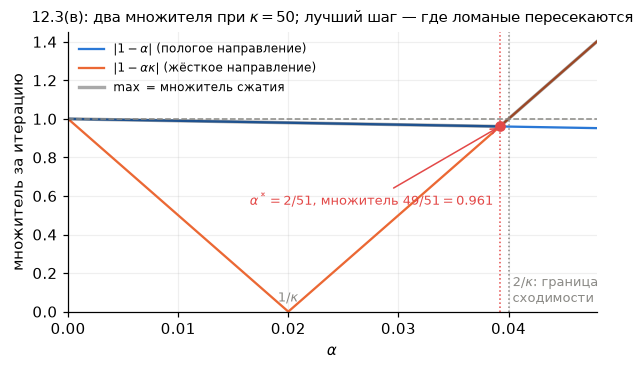

In [7]:
# (в): оба множителя как функции alpha при kappa = 50
al = np.linspace(0, 2.4 / kappa, 500)
fig, ax = plt.subplots(figsize=(6.2, 3.3))
ax.plot(al, np.abs(1 - al), color=BLUE, label="$|1-\\alpha|$ (пологое направление)")
ax.plot(al, np.abs(1 - al * kappa), color=ORANGE, label="$|1-\\alpha\\kappa|$ (жёсткое направление)")
ax.plot(al, np.maximum(np.abs(1 - al), np.abs(1 - al * kappa)), color=INK, lw=2.2, alpha=0.35, label="$\\max$ = множитель сжатия")
ax.axhline(1, color=GRAY, ls="--", lw=1)
ax.axvline(a_best, color=RED, ls=":", lw=1); ax.axvline(2 / kappa, color=GRAY, ls=":", lw=1)
ax.plot(a_best, rho(a_best), "o", color=RED, ms=6)
ax.annotate(f"$\\alpha^*=2/51$, множитель $49/51={rho(a_best):.3f}$", xy=(a_best, rho(a_best)), xytext=(0.0165, 0.55), fontsize=8.5,
            arrowprops=dict(arrowstyle="->", color=RED), color=RED)
ax.text(2 / kappa, 0.05, " $2/\\kappa$: граница\n сходимости", fontsize=8.5, color=GRAY)
ax.text(1 / kappa, 0.05, "$1/\\kappa$", fontsize=8.5, ha="center", color=GRAY)
ax.set_xlim(0, 2.4 / kappa); ax.set_ylim(0, 1.45)
ax.set_xlabel("$\\alpha$"); ax.set_ylabel("множитель за итерацию"); ax.legend(fontsize=8, loc="upper left")
ax.set_title("12.3(в): два множителя при $\\kappa=50$; лучший шаг — где ломаные пересекаются", fontsize=9.5)
plt.show()

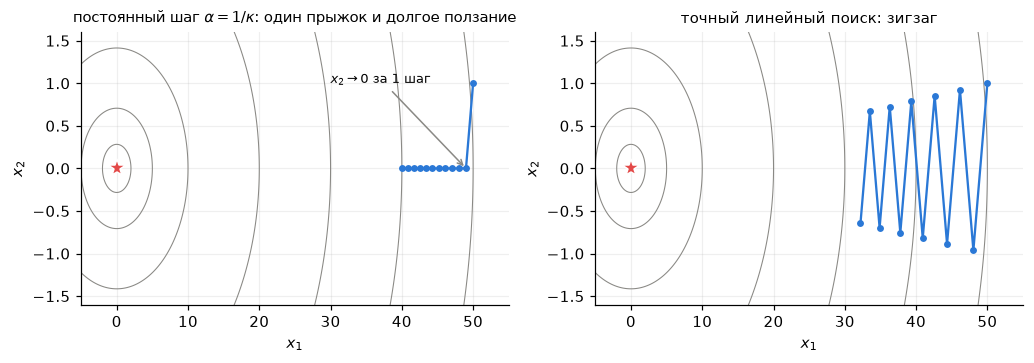

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.4))
xx, yy = np.meshgrid(np.linspace(-5, 55, 300), np.linspace(-2, 2, 200))
zz = 0.5 * (xx ** 2 + kappa * yy ** 2)
_, _, p_const = gd(fq, gq, x0, alpha=1 / kappa, tol=1e-8)
for ax, p, title in ((axs[0], p_const, "постоянный шаг $\\alpha=1/\\kappa$: один прыжок и долгое ползание"),
                     (axs[1], p_ex, "точный линейный поиск: зигзаг")):
    ax.contour(xx, yy, zz, levels=0.5 * np.array([2, 5, 10, 20, 30, 40, 50]) ** 2, colors=GRAY, linewidths=0.7)
    ax.plot(p[:12, 0], p[:12, 1], "-o", ms=3.5, color=BLUE)
    ax.plot(0, 0, "*", ms=12, color=RED, mec="white")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_title(title, fontsize=9.5)
    ax.set_xlim(-5, 55); ax.set_ylim(-1.6, 1.6)
axs[0].annotate("$x_2\\to0$ за 1 шаг", xy=(49, 0), xytext=(30, 1.0), fontsize=8.5, arrowprops=dict(arrowstyle="->", color=GRAY))
plt.tight_layout(); plt.show()

In [9]:
# (д): метры и километры
D = np.diag([1e6, 1.0])
fu = lambda u: 0.5 * u @ D @ u
gu = lambda u: D @ u
u0 = np.array([1.0, 1.0])            # 1 км по u1, 1 м по u2  <->  x0 = (1000, 1)

lam_max = D.max()
rho_u = 1 - 1 / lam_max
print(f"kappa в переменных u = {lam_max / np.diag(D).min():.0e}, множитель 1 - 1/kappa = {rho_u:.7f}, итераций на цифру = {np.log(10) / (-np.log(rho_u)):.3e}")

u, k, p_u = gd(fu, gu, u0, alpha=1 / lam_max, maxit=1000)
print(f"GD по u с шагом 1/lambda_max, 1000 итераций: u = ({u[0]:.6f}, {u[1]:.6f}); ошибка по u2 уменьшилась лишь в {u0[1] / u[1]:.6f} раз")

# предобусловленный шаг с D^{-1} = GD в метрах
fx = lambda x: 0.5 * x @ x
gx = lambda x: x
S = np.diag([1000.0, 1.0])
alpha = 0.7
u_p, x_g = u0.copy(), S @ u0
for _ in range(5):
    u_p = u_p - alpha * np.linalg.solve(D, gu(u_p))
    x_g = x_g - alpha * gx(x_g)
    assert np.allclose(S @ u_p, x_g)
print(f"после 5 предобусловленных шагов по u (alpha = {alpha}): S u = {(S @ u_p).round(6)},  GD по x даёт x = {x_g.round(6)} — совпали")

# D = hess f, alpha = 1 — шаг Ньютона: попадание за один шаг и в u, и в x
hess_u = lambda u: D
u_1 = u0 - 1.0 * np.linalg.solve(hess_u(u0), gu(u0))
_, k_nu, _ = newton(gu, hess_u, u0)
_, k_nx, _ = newton(gx, lambda x: np.eye(2), S @ u0)
print(f"D = hess f, alpha = 1: u = {u_1} — минимум за один шаг; newton() в переменных u: {k_nu} итерация, в переменных x: {k_nx} итерация — Ньютону масштаб безразличен")

kappa в переменных u = 1e+06, множитель 1 - 1/kappa = 0.9999990, итераций на цифру = 2.303e+06
GD по u с шагом 1/lambda_max, 1000 итераций: u = (0.000000, 0.999000); ошибка по u2 уменьшилась лишь в 1.001001 раз
после 5 предобусловленных шагов по u (alpha = 0.7): S u = [2.43e+00 2.43e-03],  GD по x даёт x = [2.43e+00 2.43e-03] — совпали
D = hess f, alpha = 1: u = [0. 0.] — минимум за один шаг; newton() в переменных u: 1 итерация, в переменных x: 1 итерация — Ньютону масштаб безразличен


## 12.4. Розенброк: число обусловленности и цена одной верной цифры

> Розенброк $f(x)=(1-x_1)^2+100(x_2-x_1^2)^2$. Выпишите гессиан в $(1,1)$, найдите его собственные числа и $\kappa$. Оцените, сколько итераций градиентного спуска с шагом $1/\lambda_{\max}$ нужно, чтобы вблизи минимума уменьшить ошибку в $10^6$ раз. Сравните с числом итераций из демо (часть c) и с методом Ньютона.

**Решение.**

*Шаг 1. Градиент и гессиан.* $\nabla f=\big(-2(1-x_1)-400x_1(x_2-x_1^2),\ 200(x_2-x_1^2)\big)$; в $(1,1)$ обе компоненты нули — минимум. Дифференцируя ещё раз:
$$\nabla^2f=\begin{pmatrix}2-400x_2+1200x_1^2&-400x_1\\-400x_1&200\end{pmatrix},\qquad \nabla^2f(1,1)=\begin{pmatrix}802&-400\\-400&200\end{pmatrix}.$$

*Шаг 2. Собственные числа.* След $1002$, определитель $802\cdot200-400^2=160400-160000=400$. Характеристическое уравнение $\lambda^2-1002\lambda+400=0$:
$$\lambda=\tfrac12\big(1002\pm\sqrt{1002^2-1600}\big)\approx0.3994,\ 1001.6,\qquad \kappa=\lambda_{\max}/\lambda_{\min}\approx2508.$$
Маленькое собственное число соответствует направлению вдоль дна параболической долины $x_2=x_1^2$, большое — поперёк неё.

*Приём для доски.* Когда собственные числа сильно разнесены, корень извлекать не нужно: $\lambda_{\max}+\lambda_{\min}=\operatorname{tr}$, $\lambda_{\max}\lambda_{\min}=\det$, и при $\lambda_{\min}\ll\lambda_{\max}$
$$\lambda_{\max}\approx\operatorname{tr}=1002,\qquad \lambda_{\min}\approx\frac{\det}{\operatorname{tr}}=\frac{400}{1002}\approx0.40,\qquad \kappa\approx\frac{\operatorname{tr}^2}{\det}=\frac{1002^2}{400}\approx2510.$$
Против точных $0.3994$, $1001.6$, $2508$ ошибка — доли процента (относительная погрешность приближения порядка $1/\kappa$).

*Шаг 3. Оценка числа итераций.* Вблизи минимума $f$ хорошо приближается своей квадратичной моделью, и градиентный спуск с шагом $1/\lambda_{\max}$ ведёт себя как в 12.3: вдоль «пологого» собственного направления ошибка умножается на $1-\lambda_{\min}/\lambda_{\max}=1-1/\kappa$. Уменьшить её в $10^6$ раз — это $n$ итераций с $(1-1/\kappa)^n=10^{-6}$:
$$n=\frac{\ln10^6}{-\ln(1-1/\kappa)}\approx\kappa\ln10^6\approx2508\cdot13.8\approx3.5\cdot10^4.$$

*Шаг 4. Сравнение с демо.* Постоянный шаг $0.001\approx1/\lambda_{\max}$ из $(-1.2,1)$ до $\|\nabla f\|\le10^{-6}$: **32 076** итераций. Оценка $\kappa\ln10^6\approx3.5\cdot10^4$ — **того же порядка**, но не «попала»: она про другое. Оценка говорит, за сколько итераций вблизи минимума ошибка $\|e\|$ уменьшится в $10^6$ раз по асимптотическому множителю $1-1/\kappa$; факт — это весь путь из $(-1.2,1)$ через долину до критерия $\|\nabla f\|\le10^{-6}$, где первые тысячи итераций идут не по квадратичной модели, а стартовая ошибка и конечный допуск заданы в разных величинах. Совпадение по порядку — всё, что можно требовать, и его достаточно: цена цифры определяется $\kappa$. Шаг $0.0019$, чуть меньше границы $2/\lambda_{\max}\approx0.002$, — 16 851 итерация: вдвое быстрее, как и предсказывает 12.3 (множитель вдоль пологого направления $1-\alpha\lambda_{\min}$). А при $\alpha>2/\lambda_{\max}\approx0.002$ метод **не сходится**: в отличие от квадратичной задачи из 12.3, точка не улетает на бесконечность (долина Розенброка удерживает её), а застревает в 2-цикле поперёк долины — $f$ колеблется между двумя значениями и не убывает. При $\alpha=0.002$ (чуть выше границы) картина поучительна: вдали от минимума, где локальная $\lambda_{\max}$ меньше, точка честно спускается и к 14 400-й итерации подходит вплотную ($f\approx2\cdot10^{-11}$), но вблизи $(1,1)$ шаг становится неустойчивым, колебания поперёк долины растут и точка садится на цикл с $f\approx1.25\cdot10^{-3}\leftrightarrow1.26\cdot10^{-3}$. Backtracking — 13 756 итераций: адаптивный шаг помогает в разы, но не на порядки, потому что цена определяется $\kappa$, а не выбором шага. Метод Ньютона из той же точки — **7** итераций: он использует гессиан и «видит» долину, поэтому $\kappa$ ему безразлично. Для честности сравнения — допуски: GD во всех запусках останавливается по $\|\nabla f\|\le10^{-6}$, Ньютон — по $10^{-10}$; при общем допуске $10^{-6}$ Ньютону хватает **6** итераций.

In [10]:
fr = lambda x: (1 - x[0]) ** 2 + 100 * (x[1] - x[0] ** 2) ** 2
gr = lambda x: np.array([-2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0] ** 2), 200 * (x[1] - x[0] ** 2)])
hr = lambda x: np.array([[2 - 400 * x[1] + 1200 * x[0] ** 2, -400 * x[0]], [-400 * x[0], 200.0]])

H = hr(np.array([1.0, 1.0]))
lam = np.linalg.eigvalsh(H)
kappa_r = lam[1] / lam[0]
print("гессиан в (1,1):", H.tolist())
print(f"собственные числа: {lam.round(4)},  формула (1002 ± sqrt(1002^2 - 1600))/2 = {((1002 - np.sqrt(1002**2 - 1600)) / 2):.4f}, {((1002 + np.sqrt(1002**2 - 1600)) / 2):.4f}")
print(f"kappa = {kappa_r:.1f};  оценка итераций на 10^6: kappa*ln(10^6) = {kappa_r * np.log(1e6):.0f}, точнее ln(10^6)/(-ln(1-1/kappa)) = {np.log(1e6) / (-np.log(1 - 1 / kappa_r)):.0f}")
tr, det = np.trace(H), np.linalg.det(H)
print(f"приём tr/det: lambda_max ~ tr = {tr:.0f}, lambda_min ~ det/tr = {det / tr:.4f}, kappa ~ tr^2/det = {tr ** 2 / det:.0f}  (точно: {lam[1]:.1f}, {lam[0]:.4f}, {kappa_r:.0f})")
print(f"граница устойчивости 2/lambda_max = {2 / lam[1]:.5f}")

x0 = np.array([-1.2, 1.0])
x_c, k_c, _ = gd(fr, gr, x0, alpha=0.001)
x_b, k_b, _ = gd(fr, gr, x0)
x_n, k_n, p_n = newton(gr, hr, x0)
_, k_n6, _ = newton(gr, hr, x0, tol=1e-6)
print(f"GD, шаг 0.001:  {k_c} итераций (до ||grad|| <= 1e-6), x = {x_c.round(6)}")
print(f"GD, backtracking: {k_b} итераций (до ||grad|| <= 1e-6), x = {x_b.round(6)}")
print(f"Ньютон:            {k_n} итераций (до ||grad|| <= 1e-10; при допуске 1e-6 — {k_n6}), x = {x_n.round(10)}")
print("ошибки Ньютона ||x_k - x*||:", np.array2string(np.linalg.norm(p_n - 1, axis=1), precision=2))
x_19, k_19, _ = gd(fr, gr, x0, alpha=0.0019)
print(f"GD, шаг 0.0019: {k_19} итераций, x = {x_19.round(6)}")
for a in (0.002, 0.003):
    x_d, k_d, p_d = gd(fr, gr, x0, alpha=a, maxit=50_000)
    f_path = np.array([fr(q) for q in p_d])
    print(f"GD, шаг {a}: {k_d} итераций без сходимости, |x| <= {np.abs(p_d).max():.2f} (не улетает); "
          f"min f = {f_path.min():.1e} на итерации {f_path.argmin()}, последние f: "
          + " <-> ".join(f"{v:.3e}" for v in f_path[-4:]) + " -> 2-цикл поперёк долины")

гессиан в (1,1): [[802.0, -400.0], [-400.0, 200.0]]
собственные числа: [3.9940000e-01 1.0016006e+03],  формула (1002 ± sqrt(1002^2 - 1600))/2 = 0.3994, 1001.6006
kappa = 2508.0;  оценка итераций на 10^6: kappa*ln(10^6) = 34649, точнее ln(10^6)/(-ln(1-1/kappa)) = 34643
приём tr/det: lambda_max ~ tr = 1002, lambda_min ~ det/tr = 0.3992, kappa ~ tr^2/det = 2510  (точно: 1001.6, 0.3994, 2508)
граница устойчивости 2/lambda_max = 0.00200


GD, шаг 0.001:  32076 итераций (до ||grad|| <= 1e-6), x = [0.999999 0.999998]
GD, backtracking: 13756 итераций (до ||grad|| <= 1e-6), x = [0.999999 0.999998]
Ньютон:            7 итераций (до ||grad|| <= 1e-10; при допуске 1e-6 — 6), x = [1. 1.]
ошибки Ньютона ||x_k - x*||: [2.20e+00 2.21e+00 4.18e+00 4.80e-01 5.60e-02 9.62e-06 1.85e-11 0.00e+00]
GD, шаг 0.0019: 16851 итераций, x = [0.999999 0.999998]


GD, шаг 0.002: 50000 итераций без сходимости, |x| <= 1.20 (не улетает); min f = 2.0e-11 на итерации 14397, последние f: 1.255e-03 <-> 1.250e-03 <-> 1.255e-03 <-> 1.250e-03 -> 2-цикл поперёк долины


GD, шаг 0.003: 50000 итераций без сходимости, |x| <= 1.26 (не улетает); min f = 2.8e-02 на итерации 806, последние f: 3.044e-01 <-> 3.266e-01 <-> 3.044e-01 <-> 3.266e-01 -> 2-цикл поперёк долины


## 12.5. Прочитайте график: наклон прямой, $\kappa$ и число итераций

> Градиентный спуск с постоянным шагом $1/L$ на сильно выпуклой функции стартовал с $\|\nabla f(x_0)\|=1$ и остановился по $\|\nabla f\|\le10^{-8}$; $\log_{10}\|\nabla f(x_k)\|$ лёг на прямую с наклоном $-0.0004$ на итерацию. (а) Каков множитель сжатия $q$ за итерацию и какому $\kappa$ он соответствует? (б) Сколько итераций понадобилось? (в) Стоит ли масштабировать переменные перед повторным запуском и как изменится график? (г) Как выглядел бы график, если бы метод сменили на ньютоновский?

**Решение.**

*(а) Множитель и $\kappa$.* Прямая в полулогарифмических координатах — это геометрическая прогрессия: $\log_{10}\|\nabla f_k\|=\log_{10}\|\nabla f_0\|+k\log_{10}q$, наклон равен $\log_{10}q$. Значит,
$$q=10^{-0.0004}\approx0.99908,\qquad 1-q\approx9.2\cdot10^{-4}.$$
Для шага $1/L$ на сильно выпуклой функции множитель вдоль пологого направления равен $1-\mu/L=1-1/\kappa$ (12.3, 12.4), откуда $\kappa=1/(1-q)\approx1090$. Полезно помнить связку: наклон $-0.0004$ на итерацию $\Rightarrow$ одна верная цифра стоит $1/0.0004=2500$ итераций $\Rightarrow$ $\kappa\approx2500/\ln10\approx1090$.

*(б) Число итераций.* От $\|\nabla f\|=1$ до $10^{-8}$ — восемь порядков; при наклоне $0.0004$ на итерацию это $8/0.0004=20\,000$ итераций.

*(в) Масштабировать ли.* Да. При $\kappa\sim10^3$ каждая цифра стоит $\sim2500$ итераций, и если хотя бы часть $\kappa$ пришла из единиц измерения (12.3(д)), масштабирование переменных заберёт её даром. Прямая останется прямой (метод тот же, линейная сходимость), но наклон станет круче: например, при $\kappa\approx3$ после стандартизации, как в 12.10, множитель $1-1/3$, наклон $\log_{10}(2/3)\approx-0.18$, около $-0.2$ на итерацию — цифра за пять итераций, а вместо $20\,000$ итераций — около $50$.

*(г) Если бы Ньютон.* Не прямая, а «обрыв»: при квадратичной сходимости $\log_{10}\|\nabla f_{k+1}\|\approx2\log_{10}\|\nabla f_k\|+\mathrm{const}$, число верных цифр удваивается от шага к шагу, и расстояние между соседними точками на графике растёт. От $1$ до $10^{-8}$ Ньютон дойдёт за $3$–$5$ итераций, так что график поместится в несколько точек, а его форма — не наклонная прямая, а кривая, загибающаяся вниз всё круче. Если старт далёк от минимума, первые шаги могут почти не уменьшать градиент (плато), а затем следует резкий срыв — как у Ньютона на Розенброке в 12.4.

*Проверка.* Возьмём квадратичную функцию с $\kappa=1090$ (диагональная $Q$ с собственными числами от $1$ до $1090$), старт с $\|\nabla f(x_0)\|=1$ и шаг $1/\lambda_{\max}$. Наклон хвоста должен быть $\log_{10}(1-1/1090)\approx-0.000399$, а итераций — около $20\,000$. Совпадение получается с точностью до нескольких процентов, и это нормально: во-первых, $\kappa=1090$ — округление ($q=10^{-0.0004}$ даёт $1086$); во-вторых, прямая — это **асимптотика**: первые итерации быстро гасят жёсткие компоненты градиента, и линия с наклоном $\log_{10}q$ «стартует» не с $\log_{10}1=0$, а с логарифма той части градиента, что приходится на пологое направление. Поэтому фактических итераций чуть меньше, чем $8/0.0004$, а наклон, подогнанный по всему запуску, чуть круче хвостового.

In [11]:
kappa_5 = 1090.0
n5 = 10
lam5 = np.logspace(0, np.log10(kappa_5), n5)            # собственные числа от 1 до kappa
f5 = lambda x: 0.5 * x @ (lam5 * x)
g5 = lambda x: lam5 * x
q = 10 ** -0.0004
print(f"(а) q = 10^-0.0004 = {q:.5f}, 1 - q = {1 - q:.3e}, kappa = 1/(1-q) = {1 / (1 - q):.0f} ~ 1090;  (б) 8/0.0004 = {8 / 0.0004:.0f} итераций")

# старт: все компоненты градиента одинаковы, ||grad f(x0)|| = 1
x0_5 = (np.ones(n5) / np.sqrt(n5)) / lam5
assert np.isclose(np.linalg.norm(g5(x0_5)), 1)
x5, k5, p5 = gd(f5, g5, x0_5, alpha=1 / lam5.max(), tol=1e-8, maxit=100_000)
gn5 = np.linalg.norm(p5 * lam5, axis=1)
lg5 = np.log10(gn5)
slope_tail = (lg5[-1] - lg5[-5001]) / 5000
slope_fit = np.polyfit(np.arange(len(lg5)), lg5, 1)[0]
print(f"проверка: kappa = {lam5.max() / lam5.min():.0f}, итераций до ||grad|| <= 1e-8: {k5}  (8/0.0004 = 20000, расхождение {100 * (k5 - 20000) / 20000:+.1f}%)")
print(f"          наклон хвоста {slope_tail:.6f}, log10(1 - 1/kappa) = {np.log10(1 - 1 / kappa_5):.6f}; наклон МНК по всему запуску {slope_fit:.6f}")
print(f"          доля пологой компоненты в стартовом градиенте: {1 / np.sqrt(n5):.3f}, log10 = {np.log10(1 / np.sqrt(n5)):.2f} -> прямая стартует ниже нуля, отсюда экономия ~{-np.log10(1 / np.sqrt(n5)) / 0.0004:.0f} итераций")
assert abs(slope_tail - np.log10(1 - 1 / kappa_5)) < 1e-5 and abs(k5 - 20000) / 20000 < 0.1

# (г): Ньютон на неквадратичной сильно выпуклой функции f = sum log cosh(x_i) + 0.05 ||x||^2
fn = lambda x: np.sum(np.logaddexp(x, -x) - np.log(2)) + 0.05 * x @ x
gn_ = lambda x: np.tanh(x) + 0.1 * x
hn = lambda x: np.diag(1 / np.cosh(x) ** 2 + 0.1)
c_n = root(lambda c: np.tanh(c) + 0.1 * c - 1 / np.sqrt(n5), 0.3).x[0]
x0_n = np.full(n5, c_n)                                              # все компоненты градиента равны, ||grad f(x0)|| = 1
assert np.isclose(np.linalg.norm(gn_(x0_n)), 1)
xn, kn, pn = newton(gn_, hn, x0_n, tol=1e-8)
gnn = np.array([np.linalg.norm(gn_(q_)) for q_ in pn])
print("(г) Ньютон, ||grad f_k||:", np.array2string(gnn, precision=2), f"— {kn} итераций, цифры удваиваются")

(а) q = 10^-0.0004 = 0.99908, 1 - q = 9.206e-04, kappa = 1/(1-q) = 1086 ~ 1090;  (б) 8/0.0004 = 20000 итераций
проверка: kappa = 1090, итераций до ||grad|| <= 1e-8: 18815  (8/0.0004 = 20000, расхождение -5.9%)
          наклон хвоста -0.000399, log10(1 - 1/kappa) = -0.000399; наклон МНК по всему запуску -0.000400
          доля пологой компоненты в стартовом градиенте: 0.316, log10 = -0.50 -> прямая стартует ниже нуля, отсюда экономия ~1250 итераций
(г) Ньютон, ||grad f_k||: [1.00e+00 5.46e-02 8.16e-06 2.73e-17] — 3 итераций, цифры удваиваются


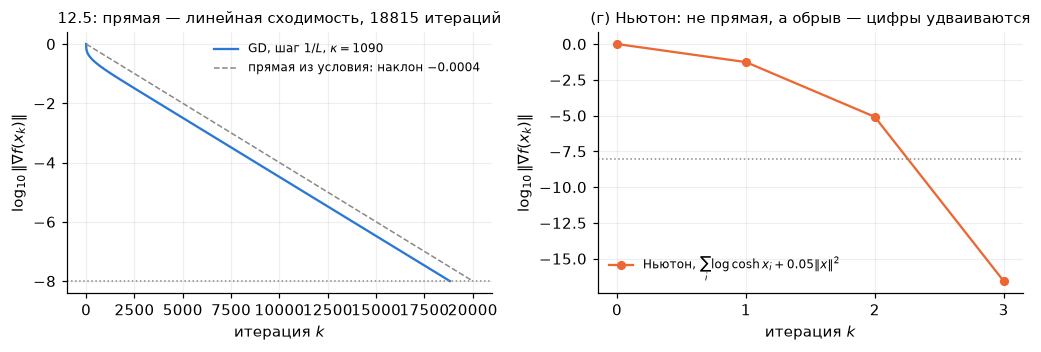

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.3))
ax = axs[0]
ax.plot(np.arange(len(lg5)), lg5, color=BLUE, lw=1.5, label="GD, шаг $1/L$, $\\kappa=1090$")
ax.plot([0, 20000], [0, -8], "--", color=GRAY, lw=1, label="прямая из условия: наклон $-0.0004$")
ax.axhline(-8, color=GRAY, ls=":", lw=1)
ax.set_xlabel("итерация $k$"); ax.set_ylabel("$\\log_{10}\\|\\nabla f(x_k)\\|$")
ax.set_title(f"12.5: прямая — линейная сходимость, {k5} итераций", fontsize=9.5); ax.legend(fontsize=8, loc="upper right")
ax = axs[1]
ax.plot(np.arange(len(gnn)), np.log10(gnn), "-o", color=ORANGE, ms=5, label="Ньютон, $\\sum_i\\log\\cosh x_i+0.05\\|x\\|^2$")
ax.axhline(-8, color=GRAY, ls=":", lw=1)
ax.set_xlabel("итерация $k$"); ax.set_ylabel("$\\log_{10}\\|\\nabla f(x_k)\\|$")
ax.set_title("(г) Ньютон: не прямая, а обрыв — цифры удваиваются", fontsize=9.5); ax.legend(fontsize=8, loc="lower left")
ax.set_xticks(np.arange(len(gnn)))
plt.tight_layout(); plt.show()

## 12.6. Лемма о спуске

> Пусть $\|\nabla f(x)-\nabla f(y)\|\le L\|x-y\|$ для всех $x,y$. Докажите, что $f(y)\le f(x)+\nabla f(x)^\top(y-x)+\tfrac L2\|y-x\|^2$ (подсказка: $f(y)-f(x)=\int_0^1\nabla f(x+t(y-x))^\top(y-x)\,dt$), и выведите $f(x-\alpha\nabla f(x))\le f(x)-\alpha\big(1-\tfrac{\alpha L}2\big)\|\nabla f(x)\|^2$. При каких $\alpha$ функция гарантированно убывает? Какой $\alpha$ даёт наибольшее гарантированное убывание? Чему равно $L$ для квадратичной $\tfrac12x^\top Qx$, $Q\succeq0$?

**Решение.**

*Шаг 1. Интегральная форма.* Пусть $\gamma(t)=x+t(y-x)$ — отрезок от $x$ к $y$. По формуле Ньютона–Лейбница для $\varphi(t)=f(\gamma(t))$, $\varphi'(t)=\nabla f(\gamma(t))^\top(y-x)$:
$$f(y)-f(x)=\int_0^1\nabla f(\gamma(t))^\top(y-x)\,dt.$$
Вычтем из обеих частей $\nabla f(x)^\top(y-x)=\int_0^1\nabla f(x)^\top(y-x)\,dt$:
$$f(y)-f(x)-\nabla f(x)^\top(y-x)=\int_0^1\big(\nabla f(\gamma(t))-\nabla f(x)\big)^\top(y-x)\,dt.$$

*Шаг 2. Оценка.* По Коши–Буняковскому и условию Липшица (с $\|\gamma(t)-x\|=t\|y-x\|$):
$$\big(\nabla f(\gamma(t))-\nabla f(x)\big)^\top(y-x)\le\|\nabla f(\gamma(t))-\nabla f(x)\|\,\|y-x\|\le Lt\|y-x\|^2.$$
Интегрируем: $\int_0^1Lt\|y-x\|^2dt=\tfrac L2\|y-x\|^2$. Получили $f(y)\le f(x)+\nabla f(x)^\top(y-x)+\tfrac L2\|y-x\|^2$: график $f$ лежит под параболой с «кривизной» $L$, касающейся его в точке $x$.

*Шаг 3. Шаг градиентного спуска.* Подставим $y=x-\alpha\nabla f(x)$, тогда $y-x=-\alpha\nabla f(x)$, $\nabla f(x)^\top(y-x)=-\alpha\|\nabla f(x)\|^2$, $\|y-x\|^2=\alpha^2\|\nabla f(x)\|^2$:
$$f(x-\alpha\nabla f(x))\le f(x)-\alpha\|\nabla f(x)\|^2+\tfrac{L\alpha^2}2\|\nabla f(x)\|^2=f(x)-\alpha\Big(1-\tfrac{\alpha L}2\Big)\|\nabla f(x)\|^2.$$

*Шаг 4. Когда убывает и какой шаг лучший.* Гарантированное убывание $\psi(\alpha)=\alpha(1-\alpha L/2)\|\nabla f\|^2$ положительно при $0<\alpha<2/L$ — та же граница $2/\lambda_{\max}$, что в 12.3. Парабола $\psi$ максимальна в вершине $\alpha=1/L$, и там
$$f(x-\tfrac1L\nabla f(x))\le f(x)-\frac1{2L}\|\nabla f(x)\|^2.$$
Так лемма отвечает на вопрос «какой шаг»: $1/L$, если $L$ известна; backtracking — способ найти шаг такого порядка, не зная $L$.

*Шаг 5. Квадратичная.* $\nabla f(x)=Qx$, $\|\nabla f(x)-\nabla f(y)\|=\|Q(x-y)\|\le\|Q\|_2\|x-y\|=\lambda_{\max}(Q)\|x-y\|$, причём равенство достигается на собственном векторе $\lambda_{\max}$. Значит, $L=\lambda_{\max}(Q)=\|Q\|$ — наименьшая константа Липшица, и «лучший шаг» $1/L=1/\lambda_{\max}$ из леммы совпадает с шагом из 12.3.

*Шаг 6. Неквадратичная $f$ и связь с гессианом.* Для дважды дифференцируемой $f$ липшицев градиент с константой $L$ равносилен ограниченному гессиану: $\|\nabla f(x)-\nabla f(y)\|\le L\|x-y\|$ для всех $x,y$ $\iff$ $-LI\preceq\nabla^2f(x)\preceq LI$ для всех $x$ (то есть $\|\nabla^2f\|\le L$). Для леммы о спуске достаточно **верхней половины** $\nabla^2f\preceq LI$: в шаге 2 нужна только оценка сверху для $(\nabla f(\gamma(t))-\nabla f(x))^\top(y-x)=\int_0^t(y-x)^\top\nabla^2f(\gamma(s))(y-x)\,ds\le Lt\|y-x\|^2$, и отрицательная кривизна ей не мешает. Поэтому в невыпуклой задаче роль $L$ играет $\sup_x\lambda_{\max}(\nabla^2f(x))$ по области, где идёт метод.

*Проверка на Розенброке.* Возьмём прямоугольник $R=[-2,2]\times[-1,3]$. Он выпуклый, поэтому для любых $x,y\in R$ отрезок $[x,y]$ лежит в $R$ — именно это нужно, чтобы интегральная формула шага 1 пользовалась оценкой гессиана только внутри $R$. Константу $L$ берём как $\max_R\lambda_{\max}(\nabla^2f)$: у Розенброка $\lambda_{\max}$ растёт при удалении от начала координат (элемент $1200x_1^2-400x_2$ и $400|x_1|$ вне диагонали), поэтому максимум достигается в углах прямоугольника, а сетка углы содержит — оценка $L\approx5327$ точная для $R$. Заметим, насколько она пессимистична: у дна долины возле $(1,1)$ локальная $\lambda_{\max}\approx1000$, и backtracking в 12.4 принимает там шаг $2^{-9}\approx0.00195$ (иногда $2^{-8}$) — на порядок больше $1/L\approx1.9\cdot10^{-4}$. Глобальная $L$ гарантирует убывание везде, но платит за это шагом, в разы меньшим нужного; backtracking находит локальную $L$ сам.

In [13]:
# Розенброк на прямоугольнике R = [-2, 2] x [-1, 3]: L оцениваем как max lambda_max(hess) по сетке
lo, hi = np.array([-2.0, -1.0]), np.array([2.0, 3.0])
grid = np.array([[a, b] for a in np.linspace(lo[0], hi[0], 201) for b in np.linspace(lo[1], hi[1], 201)])
L = max(np.linalg.eigvalsh(hr(q))[-1] for q in grid)
corners = [np.array([a, b]) for a in (lo[0], hi[0]) for b in (lo[1], hi[1])]
print(f"L = max lambda_max(hess) на сетке = {L:.1f};  в углах прямоугольника: {[round(float(np.linalg.eigvalsh(hr(c))[-1]), 1) for c in corners]} — максимум в углах (-2,-1), (2,-1)")
print(f"     для сравнения: lambda_min(hess) на сетке = {min(np.linalg.eigvalsh(hr(q))[0] for q in grid):.1f} (нижняя половина -LI <= hess не нужна лемме), lambda_max в (1,1) = {np.linalg.eigvalsh(hr(np.array([1.0, 1.0])))[-1]:.1f}")
# шаги backtracking у дна долины (из 12.4) против 1/L
_, _, p_bt = gd(fr, gr, np.array([-1.2, 1.0]))
steps = np.linalg.norm(np.diff(p_bt, axis=0), axis=1) / np.array([np.linalg.norm(gr(q)) for q in p_bt[:-1]])
vals, cnt = np.unique(np.round(np.log2(steps)), return_counts=True)
print("     шаги backtracking (из 12.4) за весь путь, 2^k: " + ", ".join(f"2^{int(v)} x{c}" for v, c in zip(vals, cnt)) + f";  в основном 2^-9 = {2 ** -9:.5f}, иногда 2^-8;  1/L = {1 / L:.2e} — глобальная L на порядок пессимистичнее")

rng = np.random.default_rng(0)
X = rng.uniform(lo, hi, size=(20_000, 2)); Y = rng.uniform(lo, hi, size=(20_000, 2))
lhs = np.array([fr(y) - fr(x) - gr(x) @ (y - x) for x, y in zip(X, Y)])
rhs = 0.5 * L * np.sum((Y - X) ** 2, axis=1)
print(f"f(y) - f(x) - grad^T (y-x) <= L/2 |y-x|^2: max отношения по 20 000 парам = {np.max(lhs / rhs):.4f} (должно быть <= 1)")
print(f"   градиент действительно L-липшицев на парах: max |g(x)-g(y)| / (L |x-y|) = {np.max([np.linalg.norm(gr(x) - gr(y)) / (L * np.linalg.norm(x - y)) for x, y in zip(X, Y)]):.4f}")
assert np.max(lhs / rhs) <= 1 + 1e-9

# шаг alpha = 1/L: убывание не меньше |grad|^2 / (2L) (для точек, у которых шаг не выводит из R)
alpha = 1 / L
ok = 0; worst = np.inf
for x in X[:5000]:
    y = x - alpha * gr(x)
    if np.all(y >= lo) and np.all(y <= hi):
        ok += 1
        worst = min(worst, (fr(x) - fr(y)) / (gr(x) @ gr(x) / (2 * L)))
print(f"шаг 1/L: по {ok} точкам фактическое убывание / гарантированное >= {worst:.3f} (должно быть >= 1)")
assert worst >= 1 - 1e-9

# квадратичная: L = lambda_max(Q), и оценка точна вдоль собственного вектора lambda_max
Qq = np.array([[3.0, 1.0], [1.0, 2.0]])
lamQ, V = np.linalg.eigh(Qq)
x, y = np.zeros(2), V[:, -1]
print(f"квадратичная 1/2 x^T Q x: lambda_max = {lamQ[-1]:.4f}; вдоль её собственного вектора f(y) - f(x) - grad^T(y-x) = {0.5 * y @ Qq @ y:.4f} = L/2 |y-x|^2 = {0.5 * lamQ[-1]:.4f}")

L = max lambda_max(hess) на сетке = 5326.8;  в углах прямоугольника: [5326.8, 3780.7, 5326.8, 3780.7] — максимум в углах (-2,-1), (2,-1)


     для сравнения: lambda_min(hess) на сетке = -1198.0 (нижняя половина -LI <= hess не нужна лемме), lambda_max в (1,1) = 1001.6


     шаги backtracking (из 12.4) за весь путь, 2^k: 2^-10 x2, 2^-9 x12998, 2^-8 x755, 2^-1 x1;  в основном 2^-9 = 0.00195, иногда 2^-8;  1/L = 1.88e-04 — глобальная L на порядок пессимистичнее
f(y) - f(x) - grad^T (y-x) <= L/2 |y-x|^2: max отношения по 20 000 парам = 0.8469 (должно быть <= 1)


   градиент действительно L-липшицев на парах: max |g(x)-g(y)| / (L |x-y|) = 0.8506
шаг 1/L: по 4997 точкам фактическое убывание / гарантированное >= 1.220 (должно быть >= 1)
квадратичная 1/2 x^T Q x: lambda_max = 3.6180; вдоль её собственного вектора f(y) - f(x) - grad^T(y-x) = 1.8090 = L/2 |y-x|^2 = 1.8090


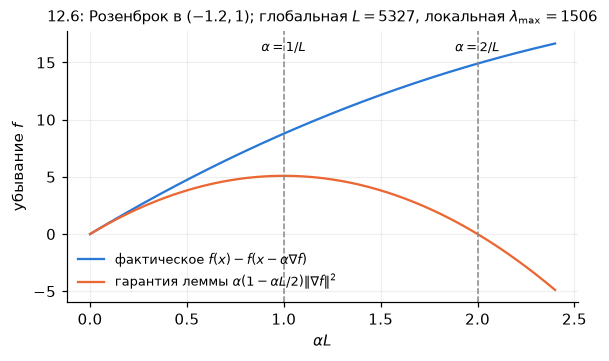

In [14]:
# гарантированное и фактическое убывание как функции alpha в точке x = (-1.2, 1)
x = np.array([-1.2, 1.0]); g = gr(x); L_loc = np.linalg.eigvalsh(hr(x))[-1]
alphas = np.linspace(0, 2.4 / L, 300)
actual = np.array([fr(x) - fr(x - a * g) for a in alphas])
guaranteed = alphas * (1 - alphas * L / 2) * (g @ g)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(alphas * L, actual, color=BLUE, label="фактическое $f(x)-f(x-\\alpha\\nabla f)$")
ax.plot(alphas * L, guaranteed, color=ORANGE, label="гарантия леммы $\\alpha(1-\\alpha L/2)\\|\\nabla f\\|^2$")
ax.axvline(1, color=GRAY, ls="--", lw=1); ax.axvline(2, color=GRAY, ls="--", lw=1)
ax.text(1, ax.get_ylim()[1] * 0.9, "$\\alpha=1/L$", ha="center", fontsize=8.5); ax.text(2, ax.get_ylim()[1] * 0.9, "$\\alpha=2/L$", ha="center", fontsize=8.5)
ax.set_xlabel("$\\alpha L$"); ax.set_ylabel("убывание $f$"); ax.legend(fontsize=8.5, loc="lower left")
ax.set_title(f"12.6: Розенброк в $(-1.2,1)$; глобальная $L={L:.0f}$, локальная $\\lambda_{{\\max}}={L_loc:.0f}$", fontsize=9.5)
plt.show()

## 12.7. Скорость сходимости по последовательности ошибок

> Скорость по последовательности. Даны ошибки $\|e_k\|$ четырёх методов: (а) $10^{-1},10^{-2},10^{-3},10^{-4},\dots$; (б) $10^{-1},10^{-2},10^{-4},10^{-8},\dots$; (в) $1/k$; (г) $1/k!$. Определите тип сходимости каждой (линейная — с каким множителем, сверхлинейная, квадратичная, ни одна из них). Сколько итераций нужно каждой, чтобы от ошибки $\le10^{-1}$ дойти до $\le10^{-12}$?

**Решение.** Определения: **линейная** — существует **одно** $q<1$ такое, что $\|e_{k+1}\|\le q\|e_k\|$ для всех $k\ge k_0$ (отношение соседних ошибок отделено от единицы; если оно стремится к пределу $q\in(0,1)$, говорят о линейной сходимости с множителем $q$); **сверхлинейная** — отношение $\|e_{k+1}\|/\|e_k\|\to0$; **квадратичная** — $\|e_{k+1}\|\le C\|e_k\|^2$ (число верных цифр удваивается). Считаем итерации от первого $k$, где ошибка $\le10^{-1}$, до первого $k$, где она $\le10^{-12}$.

*(а)* $e_k=10^{-k}$: $e_{k+1}/e_k=0.1$ — **линейная с множителем $0.1$**, одна цифра за итерацию. $\le10^{-1}$ при $k=1$, $\le10^{-12}$ при $k=12$: $11$ итераций.

*(б)* $e_k=10^{-2^k}$: $e_{k+1}/e_k=10^{-2^k}\to0$, а $e_{k+1}/e_k^2=1$ — **квадратичная** ($C=1$): показатель степени удваивается, $1\to2\to4\to8\to16$ верных цифр. От $10^{-1}$ ($k=0$): $10^{-2},\ 10^{-4},\ 10^{-8},\ 10^{-16}$ — $\le10^{-12}$ впервые при $k=4$ (после третьей итерации ещё $10^{-8}$): **4** итерации.

*(в)* $e_k=1/k$: $e_{k+1}/e_k=k/(k+1)\to1$ — **множитель не отделён от единицы**: никакого $q<1$, годного для всех $k\ge k_0$, нет, это **не линейная** сходимость (сублинейная; так сходится, например, GD на выпуклой, но не сильно выпуклой функции). $1/k\le10^{-12}$ при $k\ge10^{12}$; от $k=10$ (где ошибка $10^{-1}$) нужно $10^{12}-10\approx10^{12}$ итераций — на практике никогда.

*(г)* $e_k=1/k!$: $e_{k+1}/e_k=1/(k+1)\to0$ — **сверхлинейная**; но $e_{k+1}/e_k^2=k!/(k+1)\to\infty$, так что не квадратичная: каждый шаг прибавляет $\log_{10}(k+1)$ цифр, всё больше, но медленнее удвоения. Честная арифметика: $1/k!\le10^{-1}$ впервые при $k=4$ ($1/24\approx0.042$; при $k=3$ ещё $1/6\approx0.17>0.1$), $\le10^{-12}$ впервые при $k=15$ ($15!\approx1.31\cdot10^{12}$, $14!\approx8.7\cdot10^{10}$): $15-4=$ **11** итераций — столько же, сколько у (а), хотя (г) сверхлинейна: на таком коротком отрезке множители $1/5,\dots,1/15$ в среднем дают примерно ту же цифру за шаг, что и $0.1$, а выигрыш сверхлинейности проявился бы дальше.

Порядок по скорости: (б) $\gg$ (г) $>$ (а) $\gg$ (в). Ньютон — это (б), квазиньютоновские методы — типа (г), градиентный спуск на сильно выпуклой — (а) с $\rho=1-1/\kappa$.

In [15]:
from math import factorial

seqs = {
    "(а) 10^-k": np.array([10.0 ** -k for k in range(1, 7)]),
    "(б) 10^-2^k": np.array([10.0 ** -(2 ** k) for k in range(0, 6)]),
    "(в) 1/k": np.array([1 / k for k in range(10, 16)]),
    "(г) 1/k!": np.array([1 / factorial(k) for k in range(3, 9)]),
}
print("отношения e_{k+1}/e_k  и  e_{k+1}/e_k^2 (первые пять):")
for name, e in seqs.items():
    print(f"  {name:12s} e_{{k+1}}/e_k = {np.array2string(e[1:] / e[:-1], precision=3, floatmode='fixed')}")
    print(f"  {'':12s} e_{{k+1}}/e_k^2 = {np.array2string(e[1:] / e[:-1] ** 2, precision=3, floatmode='fixed')}")

print()
print("итераций от первого k с e_k <= 1e-1 до первого k с e_k <= 1e-12:")
first = lambda e, tol: next(k for k in range(0, 10 ** 6) if e(k) <= tol)      # первый индекс, где ошибка <= tol
seq = {"(а) 10^-k": lambda k: 10.0 ** -k if k >= 1 else 1.0,
       "(б) 10^-2^k": lambda k: 10.0 ** -(2 ** k),
       "(г) 1/k!": lambda k: 1 / factorial(k)}
for name, e in seq.items():
    k1, k2 = first(e, 1e-1), first(e, 1e-12)
    print(f"  {name:12s} старт k = {k1:2d} (e = {e(k1):.3g}), финиш k = {k2:2d} (e = {e(k2):.3g}): {k2 - k1} итераций")
print(f"  {'(в) 1/k':12s} старт k = 10, финиш k = 1e12: {1e12 - 10:.2e} итераций")

отношения e_{k+1}/e_k  и  e_{k+1}/e_k^2 (первые пять):
  (а) 10^-k    e_{k+1}/e_k = [0.100 0.100 0.100 0.100 0.100]
               e_{k+1}/e_k^2 = [1.000e+00 1.000e+01 1.000e+02 1.000e+03 1.000e+04]
  (б) 10^-2^k  e_{k+1}/e_k = [1.000e-01 1.000e-02 1.000e-04 1.000e-08 1.000e-16]
               e_{k+1}/e_k^2 = [1.000 1.000 1.000 1.000 1.000]
  (в) 1/k      e_{k+1}/e_k = [0.909 0.917 0.923 0.929 0.933]
               e_{k+1}/e_k^2 = [ 9.091 10.083 11.077 12.071 13.067]
  (г) 1/k!     e_{k+1}/e_k = [0.250 0.200 0.167 0.143 0.125]
               e_{k+1}/e_k^2 = [  1.500   4.800  20.000 102.857 630.000]

итераций от первого k с e_k <= 1e-1 до первого k с e_k <= 1e-12:
  (а) 10^-k    старт k =  1 (e = 0.1), финиш k = 12 (e = 1e-12): 11 итераций
  (б) 10^-2^k  старт k =  0 (e = 0.1), финиш k =  4 (e = 1e-16): 4 итераций
  (г) 1/k!     старт k =  4 (e = 0.0417), финиш k = 15 (e = 7.65e-13): 11 итераций
  (в) 1/k      старт k = 10, финиш k = 1e12: 1.00e+12 итераций


## 12.8. Направление наискорейшего спуска

> (а) Докажите, что среди единичных векторов $p$ производная по направлению $\nabla f(x)^\top p$ минимальна при $p=-\nabla f(x)/\|\nabla f(x)\|$. (б) Докажите, что $\nabla f(x)$ ортогонален линии уровня $\{y: f(y)=f(x)\}$ (подсказка: продифференцируйте $f(\gamma(t))=\mathrm{const}$ вдоль кривой $\gamma$ на линии уровня). (в) Покажите, что при точном линейном поиске $\nabla f(x_{k+1})\perp\nabla f(x_k)$ — отсюда зигзаг на картинке 04.

**Решение.**

*(а)* Обозначим $g=\nabla f(x)\ne0$. Производная по направлению единичного $p$ равна $g^\top p$. По неравенству Коши–Буняковского $g^\top p\ge-\|g\|\,\|p\|=-\|g\|$, причём равенство достигается ровно тогда, когда $p$ противонаправлен $g$: $p=-g/\|g\|$. Значит, минимум производной по направлению равен $-\|g\|$ и достигается только на антиградиенте. (Симметрично, максимум $+\|g\|$ — на $g/\|g\|$: градиент — направление наискорейшего подъёма.)

*(б)* Пусть $\gamma(t)$ — гладкая кривая на линии уровня, $\gamma(0)=x$, то есть $f(\gamma(t))=f(x)$ для всех $t$. Дифференцируем тождество по $t$ в нуле по правилу цепочки: $\frac d{dt}f(\gamma(t))\big|_{t=0}=\nabla f(x)^\top\gamma'(0)=0$. Вектор $\gamma'(0)$ — произвольный касательный к линии уровня в $x$; значит, $\nabla f(x)$ ортогонален всем касательным, то есть линии уровня. Вместе с (а): антиградиент — единственное направление, перпендикулярное линии уровня и смотрящее в сторону убывания.

*(в)* Точный линейный поиск: $\alpha_k=\arg\min_{\alpha\ge0}\varphi(\alpha)$, $\varphi(\alpha)=f(x_k-\alpha\nabla f(x_k))$. В минимуме (внутреннем) $\varphi'(\alpha_k)=0$, а по правилу цепочки
$$\varphi'(\alpha)=\nabla f(x_k-\alpha\nabla f(x_k))^\top(-\nabla f(x_k)),\qquad \varphi'(\alpha_k)=-\nabla f(x_{k+1})^\top\nabla f(x_k)=0.$$
Итак, следующий градиент перпендикулярен предыдущему, и соседние шаги $-\nabla f(x_{k+1})$, $-\nabla f(x_k)$ ортогональны: траектория поворачивает на $90^\circ$ на каждом шаге. По (б) это означает: точка $x_{k+1}$ — та, где прямая шага **касается** линии уровня. В $\mathbb R^2$ из ортогональности соседних градиентов следует, что $\nabla f(x_{k+2})\parallel\nabla f(x_k)$: перпендикуляр к перпендикуляру на плоскости — та же прямая, и направление **точно** повторяется через шаг. При $n>2$ это уже не обязательно — ортогональность к $\nabla f(x_{k+1})$ оставляет $n-1$ измерений свободы, — но на квадратичной задаче с одним «пологим» и одним «жёстким» направлением зигзаг быстро укладывается в двумерную плоскость, натянутую на эти два собственных вектора, и направление через шаг повторяется **почти**. На вытянутых эллипсах с $\kappa\gg1$ такие повороты дают зигзаг поперёк долины (картинка 04 и правая часть рисунка 12.3).

In [16]:
# (а): производные по случайным единичным направлениям против -|grad f| для Розенброка
rng = np.random.default_rng(1)
x = np.array([-1.2, 1.0]); g = gr(x)
th = rng.uniform(0, 2 * np.pi, 10_000)
P = np.c_[np.cos(th), np.sin(th)]
dd = P @ g
p_best = -g / np.linalg.norm(g)
print(f"(а) min по 10 000 случайным p: {dd.min():.4f} >= -|grad f| = {-np.linalg.norm(g):.4f}; на антиградиенте ровно {g @ p_best:.4f}")
assert dd.min() >= -np.linalg.norm(g) - 1e-12

# (б): касательная к линии уровня f = f(x) через параметризацию окружностью на эллипсе квадратичной 1/2(x1^2 + kappa x2^2)
kappa = 50.0; Q = np.diag([1.0, kappa])
gamma = lambda t: np.array([np.cos(t), np.sin(t) / np.sqrt(kappa)])          # f(gamma(t)) = 1/2 для всех t
t = 0.7; tangent = np.array([-np.sin(t), np.cos(t) / np.sqrt(kappa)])
print(f"(б) f(gamma(t)) = {0.5 * gamma(t) @ Q @ gamma(t):.6f} = const,  grad f^T gamma'(t) = {(Q @ gamma(t)) @ tangent:.2e}")

# (в): точный шаг на квадратичной -> соседние градиенты ортогональны
x = np.array([kappa, 1.0]); gs = [Q @ x]
for k in range(6):
    g = Q @ x
    x = x - (g @ g) / (g @ Q @ g) * g
    gs.append(Q @ x)
cos = [gs[k] @ gs[k + 1] / (np.linalg.norm(gs[k]) * np.linalg.norm(gs[k + 1])) for k in range(6)]
print("(в) cos угла между grad f(x_k) и grad f(x_{k+1}) при точном шаге:", np.array(cos).round(12))
print("    а между grad f(x_k) и grad f(x_{k+2}):", np.array([gs[k] @ gs[k + 2] / (np.linalg.norm(gs[k]) * np.linalg.norm(gs[k + 2])) for k in range(5)]).round(4), "— в R^2 через шаг направление повторяется точно")

# при n > 2 — уже только «почти»: тот же точный шаг на диагональной Q в R^3
Q3 = np.diag([1.0, 7.0, 50.0]); x3 = np.array([50.0, 3.0, 1.0]); gs3 = [Q3 @ x3]
for k in range(8):
    g = Q3 @ x3; x3 = x3 - (g @ g) / (g @ Q3 @ g) * g; gs3.append(Q3 @ x3)
cos2 = [gs3[k] @ gs3[k + 2] / (np.linalg.norm(gs3[k]) * np.linalg.norm(gs3[k + 2])) for k in range(7)]
print("    в R^3 (Q = diag(1, 7, 50)) cos между grad f(x_k) и grad f(x_{k+2}):", np.array(cos2).round(4), "— сначала не 1, потом зигзаг укладывается в плоскость двух собственных векторов")

(а) min по 10 000 случайным p: -232.8677 >= -|grad f| = -232.8677; на антиградиенте ровно -232.8677
(б) f(gamma(t)) = 0.500000 = const,  grad f^T gamma'(t) = -8.51e-17
(в) cos угла между grad f(x_k) и grad f(x_{k+1}) при точном шаге: [ 0.  0. -0.  0. -0.  0.]
    а между grad f(x_k) и grad f(x_{k+2}): [1. 1. 1. 1. 1.] — в R^2 через шаг направление повторяется точно
    в R^3 (Q = diag(1, 7, 50)) cos между grad f(x_k) и grad f(x_{k+2}): [0.993  0.9964 0.9973 0.9987 0.9991 0.9996 0.9997] — сначала не 1, потом зигзаг укладывается в плоскость двух собственных векторов


## 12.9. Цепь без пола: гессиан, $\kappa(N)$ и один шаг Ньютона

> Цепь без пола (лекция 1, §7.3). Покажите, что гессиан энергии — блочно-диагональная матрица $\operatorname{diag}(DK,\,DK)$ с трёхдиагональной $K$ ($2$ на диагонали, $-1$ рядом), не зависящая от $x$. Собственные числа $K$ равны $2-2\cos\frac{j\pi}{N+1}$, $j=1,\dots,N$ (примите без доказательства). Найдите $\kappa$ как функцию $N$ и покажите, что $\kappa\approx\big(\tfrac{2(N+1)}{\pi}\big)^2$ при больших $N$. Оцените, сколько итераций градиентного спуска нужно при $N=40$, чтобы уменьшить ошибку в $10^6$ раз, и сколько шагов Ньютона. Почему здесь Ньютон — это просто `np.linalg.solve`?

**Решение.**

*Шаг 1. Гессиан.* Энергия $E(y,z)=\tfrac D2\sum_{i=0}^{N}\big[(y_{i+1}-y_i)^2+(z_{i+1}-z_i)^2\big]+mg\sum_{i=1}^Nz_i$, концы $(y_0,z_0)$, $(y_{N+1},z_{N+1})$ закреплены. Переменная $y_i$ ($1\le i\le N$) входит в два звена: $(y_i-y_{i-1})^2$ и $(y_{i+1}-y_i)^2$, поэтому
$$\frac{\partial E}{\partial y_i}=D\,(2y_i-y_{i-1}-y_{i+1}),\qquad \frac{\partial^2E}{\partial y_i^2}=2D,\qquad \frac{\partial^2E}{\partial y_i\,\partial y_{i\pm1}}=-D,$$
остальные вторые производные по $y$ нулевые. Это матрица $DK$, где $K$ — трёхдиагональная с $2$ на диагонали и $-1$ рядом. По $z$ всё то же: линейный член $mg\sum z_i$ имеет нулевые вторые производные. Смешанных членов $y_iz_j$ в энергии нет, значит $\partial^2E/\partial y_i\partial z_j=0$. Итого $\nabla^2E=\operatorname{diag}(DK,DK)=I_2\otimes DK$ — постоянная матрица: $E$ квадратична. Она положительно определена: $v^\top Kv=v_1^2+\sum_{i=1}^{N-1}(v_{i+1}-v_i)^2+v_N^2>0$ при $v\ne0$.

*Шаг 2. $\kappa(N)$.* Собственные числа $\lambda_j=2-2\cos\frac{j\pi}{N+1}$ растут по $j$; $\lambda_{\min}=2-2\cos\frac\pi{N+1}$, $\lambda_{\max}=2-2\cos\frac{N\pi}{N+1}=2+2\cos\frac\pi{N+1}$ (поскольку $\cos(\pi-\theta)=-\cos\theta$). Множитель $D$ и блочность на $\kappa$ не влияют:
$$\kappa(N)=\frac{1+\cos\frac\pi{N+1}}{1-\cos\frac\pi{N+1}}.$$
При больших $N$ угол $\theta=\pi/(N+1)$ мал, $\cos\theta\approx1-\theta^2/2$, и
$$\kappa\approx\frac{2}{\theta^2/2}=\frac4{\theta^2}=\Big(\frac{2(N+1)}\pi\Big)^2.$$
Число обусловленности растёт как $N^2$: чем мельче делим цепь, тем хуже обусловлена задача (это общее свойство дискретизаций второй производной). Для $N=10,20,40,80$: $\kappa=48.4,\ 178.1,\ 680.6,\ 2658.4$, формула даёт $49.0,\ 178.7,\ 681.3,\ 2659.1$.

*Шаг 3. Итерации при $N=40$.* $\kappa\approx681$; с шагом $1/L$, $L=\lambda_{\max}(\nabla^2E)=D\lambda_{\max}(K)\approx279.6$, множитель $1-1/\kappa$, и на $10^6$ раз нужно $\approx\kappa\ln10^6\approx681\cdot13.8\approx9.4\cdot10^3$ итераций. Чтобы сравнить с запуском честно, оценим в тех же величинах, что и критерий остановки: из прямой между концами $\|\nabla E(v_0)\|\approx6.2$, а стоп — по $\|\nabla E\|\le10^{-6}$, то есть градиент должен уменьшиться в $6.2\cdot10^6$ раз. Градиент, как и ошибка, сжимается с множителем $1-1/\kappa$, поэтому оценка — $\kappa\ln(6.2\cdot10^6)\approx681\cdot15.6\approx10\,640$ итераций против фактических **10 575**: здесь функция квадратична, и асимптотика работает с первого шага.

*Шаг 4. Ньютон — один шаг.* Квадратичная модель $E(x+p)\approx E(x)+\nabla E(x)^\top p+\tfrac12p^\top\nabla^2E\,p$ для квадратичной $E$ — не приближение, а тождество. Шаг Ньютона $p=-(\nabla^2E)^{-1}\nabla E(x)$ приводит в точку с $\nabla E=0$, то есть в минимум, из любого старта за **одну** итерацию (вторая — только чтобы убедиться, что градиент нулевой). Поскольку $\nabla E(x)=Hx+b$ с постоянной $H$, условие $\nabla E=0$ — линейная система $Hx=-b$, и Ньютон здесь буквально `np.linalg.solve(H, -grad(0))`: решение линейной системы с разреженной (блочно-трёхдиагональной) матрицей. Минимальная энергия $E^\ast=13.4417$.

In [17]:
N, D, g = 40, 70.0, 9.81
m = 4.0 / N
p_left, p_right = np.array([-2.0, 1.0]), np.array([2.0, 1.0])

def unpack(v):
    y = np.concatenate(([p_left[0]], v[:N], [p_right[0]]))
    z = np.concatenate(([p_left[1]], v[N:], [p_right[1]]))
    return y, z

def energy(v):
    y, z = unpack(v)
    return 0.5 * D * np.sum(np.diff(y) ** 2 + np.diff(z) ** 2) + m * g * np.sum(z[1:-1])

def grad_E(v):
    y, z = unpack(v)
    gy = D * (2 * y[1:-1] - y[:-2] - y[2:])
    gz = D * (2 * z[1:-1] - z[:-2] - z[2:]) + m * g
    return np.concatenate((gy, gz))

K = 2 * np.eye(N) - np.eye(N, k=1) - np.eye(N, k=-1)
H = np.kron(np.eye(2), D * K)
# гессиан численно: градиент линеен, поэтому разности точны
H_num = np.column_stack([grad_E(e) - grad_E(np.zeros(2 * N)) for e in np.eye(2 * N)])
print(f"гессиан = kron(I_2, D K): max |H_num - H| = {np.abs(H_num - H).max():.1e}; блок y-z: max = {np.abs(H_num[:N, N:]).max():.1e}")

print(" N    kappa(K)   (2(N+1)/pi)^2   max|lambda_j - формула|")
for n in (10, 20, 40, 80):
    Kn = 2 * np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1)
    ev = np.linalg.eigvalsh(Kn)
    formula = 2 - 2 * np.cos(np.arange(1, n + 1) * np.pi / (n + 1))
    print(f"{n:3d}  {ev[-1] / ev[0]:9.1f}  {(2 * (n + 1) / np.pi) ** 2:13.1f}   {np.abs(np.sort(formula) - ev).max():.1e}")

L = np.linalg.eigvalsh(H)[-1]
kappa_c = np.linalg.eigvalsh(H)[-1] / np.linalg.eigvalsh(H)[0]
print(f"N = 40: L = lambda_max(H) = {L:.2f}, kappa = {kappa_c:.1f}, оценка kappa*ln(1e6) = {kappa_c * np.log(1e6):.0f} итераций")

v0 = np.concatenate((np.linspace(p_left[0], p_right[0], N + 2)[1:-1], np.linspace(p_left[1], p_right[1], N + 2)[1:-1]))
v_newton = v0 - np.linalg.solve(H, grad_E(v0))          # один шаг Ньютона
print(f"один шаг Ньютона: E = {energy(v_newton):.4f}, |grad E| = {np.linalg.norm(grad_E(v_newton)):.1e}")
v_n2, k_n, _ = newton(grad_E, lambda v: H, v0)
print(f"newton(): {k_n} итерация(и) до ||grad|| <= 1e-10, та же точка: {np.linalg.norm(v_n2 - v_newton):.1e}")
gn0 = np.linalg.norm(grad_E(v0))
print(f"||grad E(v0)|| = {gn0:.2f}; оценка kappa*ln(||grad E(v0)|| / 1e-6) = {kappa_c * np.log(gn0 / 1e-6):.0f} итераций")
v_gd, k_gd, _ = gd(energy, grad_E, v0, alpha=1 / L)
print(f"GD с шагом 1/L: {k_gd} итераций до ||grad|| <= 1e-6, E = {energy(v_gd):.4f}, расстояние до решения Ньютона {np.linalg.norm(v_gd - v_newton):.1e}")

гессиан = kron(I_2, D K): max |H_num - H| = 0.0e+00; блок y-z: max = 0.0e+00
 N    kappa(K)   (2(N+1)/pi)^2   max|lambda_j - формула|
 10       48.4           49.0   4.4e-16
 20      178.1          178.7   1.3e-15
 40      680.6          681.3   1.8e-15
 80     2658.4         2659.1   2.2e-15
N = 40: L = lambda_max(H) = 279.59, kappa = 680.6, оценка kappa*ln(1e6) = 9403 итераций
один шаг Ньютона: E = 13.4417, |grad E| = 1.5e-13
newton(): 1 итерация(и) до ||grad|| <= 1e-10, та же точка: 0.0e+00
||grad E(v0)|| = 6.20; оценка kappa*ln(||grad E(v0)|| / 1e-6) = 10645 итераций


GD с шагом 1/L: 10575 итераций до ||grad|| <= 1e-6, E = 13.4417, расстояние до решения Ньютона 2.4e-06


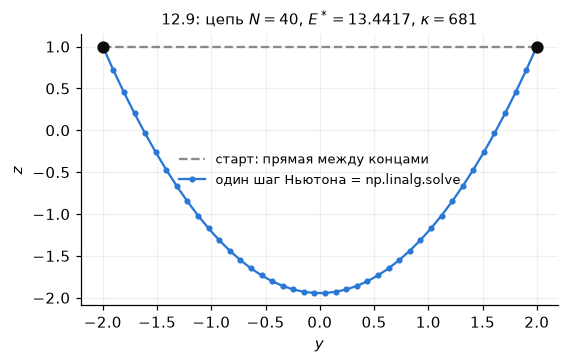

In [18]:
y0, z0 = unpack(v0); y1, z1 = unpack(v_newton)
fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(y0, z0, "--", color=GRAY, label="старт: прямая между концами")
ax.plot(y1, z1, "-o", ms=3, color=BLUE, label="один шаг Ньютона = np.linalg.solve")
ax.plot([-2, 2], [1, 1], "o", color=INK, ms=7)
ax.set_xlabel("$y$"); ax.set_ylabel("$z$"); ax.legend(fontsize=8.5, loc="center")
ax.set_title(f"12.9: цепь $N={N}$, $E^*={energy(v_newton):.4f}$, $\\kappa={kappa_c:.0f}$", fontsize=10)
plt.show()

## 12.10. Логистическая регрессия: выпуклость и масштаб признаков

> Логистическая регрессия (лекция 1, §7.5; данные — демо лекции 2, часть d). Для $f(w)=\frac1n\sum_{i=1}^n\log\big(1+e^{-y_i\,x_i^\top w}\big)$, $y_i\in\{-1,1\}$, найдите $\nabla f$ и $\nabla^2f$ и покажите, что $\nabla^2f=\frac1nX^\top SX$ с диагональной $S\succeq0$. Гессиан — взвешенная матрица вторых моментов признаков: объясните, почему признак «возраст $40\pm10$» вместе со столбцом единиц даёт большое $\kappa$ (подсказка: столбцы почти коллинеарны), почему одно масштабирование признаков этого не лечит, а стандартизация — сдвиг плюс масштаб — лечит.

**Решение.**

*Шаг 1. Градиент.* Обозначим $\sigma(t)=1/(1+e^{-t})$ и $\ell(t)=\log(1+e^{-t})$; тогда $f(w)=\frac1n\sum_i\ell(y_ix_i^\top w)$. Производная $\ell'(t)=\dfrac{-e^{-t}}{1+e^{-t}}=-\sigma(-t)$. По правилу цепочки
$$\nabla f(w)=\frac1n\sum_{i=1}^n\ell'(y_ix_i^\top w)\,y_ix_i=-\frac1n\sum_{i=1}^n\sigma(-y_ix_i^\top w)\,y_i\,x_i.$$
Смысл: $\sigma(-y_ix_i^\top w)$ — вероятность, которую модель приписывает **неправильному** классу; чем увереннее ошибка, тем сильнее объект тянет $w$.

*Шаг 2. Гессиан.* $\sigma'(t)=\sigma(t)(1-\sigma(t))$ и $\sigma(-t)=1-\sigma(t)$, поэтому $\frac d{dt}\big[-\sigma(-t)\big]=\sigma'(-t)=\sigma(t)(1-\sigma(t))$. Дифференцируя $\nabla f$ ещё раз по $w$ (внутри снова множитель $y_ix_i$, а $y_i^2=1$):
$$\nabla^2f(w)=\frac1n\sum_{i=1}^n\sigma(z_i)(1-\sigma(z_i))\,x_ix_i^\top=\frac1nX^\top SX,\qquad z_i=x_i^\top w,\quad S=\operatorname{diag}\big(\sigma(z_i)(1-\sigma(z_i))\big).$$
Заметим, что $y_i$ из гессиана исчез: кривизна зависит только от того, насколько уверенно модель классифицирует объект, а не от того, права ли она.

*Шаг 3. Выпуклость.* Диагональ $S$ неотрицательна ($\sigma\in(0,1)$), значит для любого $v$
$$v^\top\nabla^2f(w)\,v=\frac1n(Xv)^\top S(Xv)=\frac1n\sum_is_i(x_i^\top v)^2=\frac1n\|S^{1/2}Xv\|^2\ge0.$$
Гессиан $\succeq0$ всюду — $f$ выпукла. Строго выпукла, если столбцы $X$ линейно независимы (тогда $Xv\ne0$ при $v\ne0$, а $s_i>0$). Значит, любая стационарная точка — глобальный минимум, и градиентный спуск с Ньютоном находят его без оговорок.

*Шаг 4. Гессиан как матрица вторых моментов.* $\frac1nX^\top SX\approx\bar s\cdot\frac1nX^\top X$, если веса $s_i$ не слишком различаются, а $\frac1nX^\top X$ — матрица **вторых моментов** признаков: элемент $(j,l)$ равен $\frac1n\sum_ix_{ij}x_{il}$. Ключевое: второй момент — это не дисперсия, а $\text{среднее}^2+\text{дисперсия}$. У данных демо столбцы: единицы, возраст (среднее $\approx40$, дисперсия $\approx100$), стаж (среднее $\approx5$, дисперсия $\approx1$). Второй момент возраста $\approx1600+100=1700$, и почти весь он — от среднего, а не от разброса.

*Шаг 5. Почему возраст со столбцом единиц даёт большое $\kappa$.* Косинус угла между столбцом возраста $a$ и столбцом единиц $\mathbf1$:
$$\cos\angle(a,\mathbf1)=\frac{\bar a}{\sqrt{\bar a^2+\operatorname{var}a}}=\frac{40}{\sqrt{1600+100}}\approx0.97.$$
Столбцы **почти коллинеарны**: возраст $40\pm10$ — это «константа $40$ плюс небольшая добавка». Для матрицы $\frac1nX^\top X$ это означает: вдоль $v=(-40,1,0)$ имеем $Xv=a-40\mathbf1$, отношение Рэлея $\frac{\|Xv\|^2/n}{\|v\|^2}\approx\frac{\operatorname{var}a}{1+40^2}\approx0.06$ — маленькое собственное число (оно же, с весами $s_i\le1/4$ и ещё одной почти-коллинеарностью — стажа с единицами, — даёт $\lambda_{\min}\approx0.003$ у гессиана); а вдоль $v=(1,40,0)$ получаем $Xv\approx(1+40^2)\mathbf1$ и отношение Рэлея $\approx1+40^2\approx1600$ — большое собственное число. Отношение растёт как $\bar a^4/\operatorname{var}a$, и получается $\kappa\approx7.5\cdot10^4$. Виноваты не единицы измерения, а **сдвиг**: среднее признака велико по сравнению с его разбросом.

*Шаг 6. Почему одно масштабирование не лечит.* Разделим возраст на его std (или на $10$): столбец станет $4\pm1$. Косинус с $\mathbf1$ **не изменился** — умножение столбца на число угол не меняет, коллинеарность осталась (то же для стажа: $5\pm1$, косинус $\approx0.98$). Масштабирование выравнивает диагональ, то есть убирает разницу $\lambda_{\max}$ между признаками, но маленькое собственное число, порождённое почти-коллинеарностью, остаётся: $\kappa$ падает с $7.5\cdot10^4$ до $\sim2\cdot10^3$ и не дальше. Одно масштабирование — это то, что лечило 12.3(д), где всё $\kappa$ было из единиц; здесь же основная часть $\kappa$ из сдвига.

*Шаг 7. Стандартизация — сдвиг плюс масштаб.* Заменим $x_{ij}\leftarrow(x_{ij}-\mu_j)/\sigma_j$ для всех признаков, кроме константы. Вычитание среднего делает столбцы признаков **ортогональными** столбцу единиц ($\sum_i(x_{ij}-\mu_j)=0$, косинус ровно $0$), деление на std ставит единицы на диагональ, и $\frac1nX^\top X$ превращается в блок $\operatorname{diag}(1,\ \text{корреляционная матрица признаков})$: собственные числа порядка единицы, $\kappa$ определяется только корреляциями признаков между собой. Это линейная замена $x\to Ax+b$, то есть замена переменных $w\to A^{-\top}w$ с пересчётом свободного члена, — задача та же, а $\kappa$ другой: предобусловливатель, выбранный по данным. Итог в проверке: сырые данные $\kappa\approx7.5\cdot10^4$ (GD с backtracking не доходит до $\|\nabla f\|\le10^{-6}$ за 20 000 итераций); только масштаб — $\kappa\approx2\cdot10^3$; стандартизация — $\kappa\approx2.75$ и 195 итераций. Ньютону всё это безразлично — 6 итераций во всех трёх вариантах, $w^\ast$ один и тот же с точностью до пересчёта, точность $\approx0.81$.

In [19]:
# формулы для y in {-1, 1}
f_log = lambda w, X, y: np.mean(np.logaddexp(0, -y * (X @ w)))
g_log = lambda w, X, y: -X.T @ (expit(-y * (X @ w)) * y) / len(y)
h_log = lambda w, X, y: (X.T * (expit(X @ w) * (1 - expit(X @ w)))) @ X / len(y)

# проверка конечными разностями на случайных данных
rng = np.random.default_rng(10)
Xr = np.c_[np.ones(30), rng.normal(size=(30, 3))]; yr = rng.choice([-1.0, 1.0], size=30); wr = rng.normal(size=4)
eps = 1e-6
g_fd = np.array([(f_log(wr + eps * e, Xr, yr) - f_log(wr - eps * e, Xr, yr)) / (2 * eps) for e in np.eye(4)])
h_fd = np.column_stack([(g_log(wr + eps * e, Xr, yr) - g_log(wr - eps * e, Xr, yr)) / (2 * eps) for e in np.eye(4)])
print(f"градиент vs конечные разности: max|diff| = {np.abs(g_log(wr, Xr, yr) - g_fd).max():.1e}")
print(f"гессиан  vs конечные разности: max|diff| = {np.abs(h_log(wr, Xr, yr) - h_fd).max():.1e}")
ev = np.linalg.eigvalsh(h_log(wr, Xr, yr))
print(f"собственные числа гессиана: {ev.round(4)} — все >= 0, выпукла")
assert ev.min() >= 0

# данные демо (часть d): возраст и стаж
rng = np.random.default_rng(4); n = 200
z1, z2 = rng.normal(0, 1, n), rng.normal(0, 1, n)
p = 1 / (1 + np.exp(-(1.5 * z1 - 1.0 * z2 + 0.3)))
y01 = (rng.uniform(size=n) < p).astype(float)
y = 2 * y01 - 1                                                       # {0,1} -> {-1,1}
age, exp_years = 40 + 10 * z1, 5 + z2
X = np.c_[np.ones(n), age, exp_years]
mu, sd = X[:, 1:].mean(0), X[:, 1:].std(0)
print(f"столбцы: возраст — среднее {mu[0]:.1f}, дисперсия {sd[0] ** 2:.1f};  стаж — среднее {mu[1]:.2f}, дисперсия {sd[1] ** 2:.2f}")
print("диагональ X^T X / n (вторые моменты = среднее^2 + дисперсия):", (X.T @ X / n).diagonal().round(1))
cosang = lambda u, v: u @ v / (np.linalg.norm(u) * np.linalg.norm(v))
print(f"cos угла между столбцом возраста и столбцом единиц: {cosang(X[:, 1], X[:, 0]):.4f}  (формула 40/sqrt(1600+100) = {40 / np.sqrt(1700):.4f});  стаж и единицы: {cosang(X[:, 2], X[:, 0]):.4f}")

Xm = X.copy(); Xm[:, 1:] = X[:, 1:] / sd                         # только масштаб
Xs = X.copy(); Xs[:, 1:] = (X[:, 1:] - mu) / sd                  # стандартизация: сдвиг + масштаб
print()
for name, XX in (("сырые признаки      ", X), ("только масштаб      ", Xm), ("стандартизация      ", Xs)):
    w_star, k_newton, _ = newton(lambda w: g_log(w, XX, y), lambda w: h_log(w, XX, y), np.zeros(3))
    ev = np.linalg.eigvalsh(h_log(w_star, XX, y))
    w_gd, k_gd, _ = gd(lambda w: f_log(w, XX, y), lambda w: g_log(w, XX, y), np.zeros(3), maxit=20_000)
    print(f"{name}: cos(возраст, 1) = {cosang(XX[:, 1], XX[:, 0]):.3f}, собственные числа гессиана {ev.round(4)}, kappa = {ev[-1] / ev[0]:.4g}; "
          f"Ньютон {k_newton} ит., GD backtracking {k_gd} ит.{' (не сошёлся)' if k_gd == 20_000 else ''}; w* = {w_star.round(3)}")
print(f"точность классификации на обучающей выборке: {np.mean((Xs @ w_star > 0) == (y > 0)):.3f}")

градиент vs конечные разности: max|diff| = 1.0e-10
гессиан  vs конечные разности: max|diff| = 4.5e-11
собственные числа гессиана: [0.0449 0.0906 0.1131 0.2298] — все >= 0, выпукла
столбцы: возраст — среднее 40.5, дисперсия 99.5;  стаж — среднее 5.02, дисперсия 1.05
диагональ X^T X / n (вторые моменты = среднее^2 + дисперсия): [1.0000e+00 1.7381e+03 2.6300e+01]
cos угла между столбцом возраста и столбцом единиц: 0.9710  (формула 40/sqrt(1600+100) = 0.9701);  стаж и единицы: 0.9798



сырые признаки      : cos(возраст, 1) = 0.971, собственные числа гессиана [3.000000e-03 1.567000e-01 2.247292e+02], kappa = 7.506e+04; Ньютон 6 ит., GD backtracking 20000 ит. (не сошёлся); w* = [-1.552  0.181 -1.023]


только масштаб      : cos(возраст, 1) = 0.971, собственные числа гессиана [3.0000e-03 5.7600e-02 5.9196e+00], kappa = 2000; Ньютон 6 ит., GD backtracking 7495 ит.; w* = [-1.552  1.802 -1.049]
стандартизация      : cos(возраст, 1) = 0.000, собственные числа гессиана [0.0541 0.1254 0.1487], kappa = 2.749; Ньютон 6 ит., GD backtracking 195 ит.; w* = [ 0.623  1.802 -1.049]
точность классификации на обучающей выборке: 0.815


## Что запомнить

- $\nabla f=0$ — необходимое условие: градиентный спуск останавливается в любой стационарной точке, в том числе в седле, но к седлу приходит только со множества меры нуль (12.1). Гессиан с нулевым собственным числом ничего не решает — там всё определяют старшие члены, и проверка «по направлениям» не заменяет $\nabla^2f\succ0$ (пример Пеано, 12.2).
- На квадратичной с постоянным шагом ошибка вдоль каждого собственного направления сжимается в $|1-\alpha\lambda_i|$ раз; сходимость при $0<\alpha<2/\lambda_{\max}$, лучший постоянный шаг $2/(\lambda_{\max}+\lambda_{\min})$ с множителем $(\kappa-1)/(\kappa+1)$ для $\|e\|$ и его квадратом для $f-f^\ast$; точный шаг не быстрее; итераций на одну цифру $\sim\kappa$ (12.3, 12.4, 12.9).
- $\kappa$ зависит от единиц измерения и от сдвига: масштабирование переменных — самый дешёвый предобусловливатель, а при признаках с большим средним нужна ещё и центровка (12.3(д), 12.10). Наклон прямой $\log_{10}\|\nabla f_k\|$ — это $\log_{10}(1-1/\kappa)$: по графику читается $\kappa$ и цена цифры (12.5).
- Лемма о спуске: при $L$-липшицевом градиенте ($\nabla^2f\preceq LI$) шаг $1/L$ гарантирует убывание на $\|\nabla f\|^2/(2L)$; для квадратичной $L=\lambda_{\max}$; глобальная $L$ обычно пессимистична, backtracking находит локальную (12.6).
- Типы сходимости различают по отношению соседних ошибок: отделено от единицы одним $q<1$ — линейная, $\to0$ — сверхлинейная, $\|e_{k+1}\|\le C\|e_k\|^2$ — квадратичная (12.7).
- Антиградиент — направление наискорейшего спуска, он перпендикулярен линии уровня, а при точном линейном поиске соседние градиенты ортогональны — отсюда зигзаг (12.8).
- Для квадратичной функции метод Ньютона — один шаг, то есть решение линейной системы; для выпуклой логистической регрессии — несколько (12.9, 12.10).